# NHS A&E Demand Shock Resilience - Technical Notebook

End-to-end pipeline: **data ingestion → preparation → audit → shock detection → resilience scoring → clustering → robustness checks → secondary predictive analysis**.

**Research question:** How well do NHS acute trusts maintain 4-hour A&E performance during periods of unusually high demand, and can trusts be grouped by their demand-shock resilience profile?

**Data:** NHS England A&E statistics from January 2014 to December 2019. Monthly files cover July 2015 to December 2019; weekly files cover January 2014 to June 2015 and are aggregated to provider-month level. NHS succession mappings in `data/succ.csv` are used to split provider time series around merger events.


In [1]:
import glob
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

%matplotlib inline
warnings.filterwarnings("ignore")

C_BLUE = "#2166AC"
C_RED = "#D6404E"
C_GREEN = "#4DAC26"
C_ORANGE = "#E08B2C"
C_GRAY = "#AAAAAA"
C_DARK = "#2D2D2D"

CLUSTER_COLORS = [C_BLUE, C_RED, C_GREEN, C_ORANGE]
EVIDENCE_PALETTE = {"low": C_GRAY, "medium": C_BLUE, "high": C_GREEN}

sns.set_theme(style="ticks")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#CCCCCC",
    "axes.linewidth": 0.8,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#F0F0F0",
    "grid.linewidth": 0.7,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.titlepad": 10,
    "axes.labelsize": 10,
    "axes.labelcolor": "#333333",
    "axes.labelpad": 6,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "xtick.color": "#555555",
    "ytick.color": "#555555",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.major.width": 0.7,
    "ytick.major.width": 0.7,
    "legend.fontsize": 9,
    "legend.frameon": False,
    "lines.linewidth": 2,
    "figure.figsize": (12, 4.5),
    "figure.dpi": 110,
})


def as_bool(s):
    if pd.api.types.is_bool_dtype(s):
        return s.fillna(False)
    return s.astype(str).str.lower().isin(["true", "1", "yes"])


In [2]:
BASE_DIR = Path(".").resolve()
DATA_DIR = BASE_DIR / "data"
SUCC_PATH = DATA_DIR / "succ.csv"
OUTPUT_DIR = BASE_DIR.parent

FULL_PANEL_PATH = OUTPUT_DIR / "ae_panel_full.csv"
ANALYSIS_READY_PATH = OUTPUT_DIR / "ae_panel_analysis_ready.csv"
WITH_SHOCKS_PATH = OUTPUT_DIR / "ae_panel_with_shocks.csv"
SHOCK_SUMMARY_PATH = OUTPUT_DIR / "trust_shock_summary.csv"
RESILIENCE_PATH = OUTPUT_DIR / "trust_resilience_scores.csv"
CLUSTERS_PATH = OUTPUT_DIR / "trust_resilience_clusters.csv"

ROLLING_WINDOW = 12
MIN_PERIODS = 12
ZSCORE_THRESHOLD = 2.0
RATIO_THRESHOLD = 1.15
SHRINKAGE_K = 5
N_CLUSTERS = 3
RANDOM_STATE = 42


## 1. Build Dataset

Reads all source files and saves a unified provider-month panel.

**Monthly files** (`data/YY/YY-mon.xls`, July 2015-December 2019): each file is one calendar month already. Columns are matched by exact name using `find_exact_col` to handle whitespace/newline variants in the headers.

**Weekly files** (`data/weekly/YYYY.MM.DD-AE-XXXXX.xls`, January 2014-June 2015): weeks are assigned to the calendar month of their week-ending date and summed. Attendance counts are summed directly; `pct_4hr_all` is reconstructed as a weighted mean (`Σ(att × pct) / Σ att`), because averaging provider percentages directly would be volume-biased.

**Boundary note:** weeks straddling a month boundary are assigned to the month they end in, so a small number of days may be counted in the adjacent month. This is a limitation of the available weekly format. The shock detector later compares attendance with the same calendar month in prior years, which reduces but does not fully remove this boundary approximation.


In [3]:
import re as _re

month_map = {
    "jan": "01", "feb": "02", "mar": "03", "apr": "04",
    "may": "05", "jun": "06", "jul": "07", "aug": "08",
    "sep": "09", "oct": "10", "nov": "11", "dec": "12",
}

def clean_col(c):
    return str(c).lower().strip().replace("\n", " ")

def find_exact_col(raw_df, target):
    t = clean_col(target)
    for col in raw_df.columns:
        if clean_col(col) == t:
            return col
    return None

def read_weekly_file(file):
    fname = Path(file).name
    m = _re.match(r"(\d{4})\.(\d{2})\.(\d{2})", fname)
    if not m:
        return None
    file_month = pd.to_datetime(f"{m.group(1)}-{m.group(2)}-01")

    raw = pd.read_excel(file, skiprows=15).dropna(axis=0, how="all")

    code_col = find_exact_col(raw, "Code")
    name_col = find_exact_col(raw, "Name")
    att_col  = find_exact_col(raw, "Total attendances")
    pct_col  = find_exact_col(raw, "Percentage in 4 hours or less (all)")
    w12_col  = find_exact_col(raw, "Number of patients spending >12 hours from decision to admit to admission")

    if any(c is None for c in [code_col, name_col, att_col, pct_col, w12_col]):
        missing = [n for n, c in zip(["Code","Name","att","pct4hr",">12hr"],
                                     [code_col,name_col,att_col,pct_col,w12_col]) if c is None]
        print(f"  SKIPPED {fname}: missing {missing}")
        return None

    region_col = find_exact_col(raw, "Region") or find_exact_col(raw, "Area Team")

    adm_col = find_exact_col(raw, "Total Emergency Admissions")

    w4_col  = find_exact_col(raw, "Number of patients spending >4 hours from decision to admit to admission")

    df = pd.DataFrame({
        "provider_code":   raw[code_col],
        "provider_name":   raw[name_col],
        "region":          raw[region_col] if region_col else "",
        "att_total":       pd.to_numeric(raw[att_col],  errors="coerce"),
        "pct_4hr_all":     pd.to_numeric(raw[pct_col],  errors="coerce"),
        "wait_12hr_dta":   pd.to_numeric(raw[w12_col],  errors="coerce"),
    })

    if adm_col:
        df["emerg_adm_total"] = pd.to_numeric(raw[adm_col], errors="coerce")
    else:
        sub_adm = [
            "Emergency Admissions via Type 1 A&E",
            "Emergency Admissions via Type 2 A&E",
            "Emergency Admissions via Type 3 and 4 A&E",
            "Other Emergency admissions (i.e not via A&E)",
        ]
        found = [find_exact_col(raw, s) for s in sub_adm]
        if all(c is not None for c in found):
            df["emerg_adm_total"] = sum(pd.to_numeric(raw[c], errors="coerce") for c in found)
        else:
            df["emerg_adm_total"] = float("nan")

    if w4_col:
        df["wait_4hr_dta"] = pd.to_numeric(raw[w4_col], errors="coerce")
    else:
        w4_sub = find_exact_col(raw, "Number of patients spending >4 hours but <12 hours from decision to admit to adm")
        if w4_sub is None:
            for col in raw.columns:
                if ">4 hours but <12" in str(col):
                    w4_sub = col
                    break
        if w4_sub:
            df["wait_4hr_dta"] = (pd.to_numeric(raw[w4_sub], errors="coerce") +
                                  pd.to_numeric(raw[w12_col], errors="coerce"))
        else:
            df["wait_4hr_dta"] = float("nan")

    df["month"] = file_month
    return df


weekly_files = sorted(glob.glob(str(DATA_DIR / "weekly" / "*.xls")))
weekly_rows  = []

for file in weekly_files:
    df_w = read_weekly_file(file)
    if df_w is not None:
        weekly_rows.append(df_w)

if weekly_rows:
    wk = pd.concat(weekly_rows, ignore_index=True)
    wk = wk[wk["provider_code"].notna() & wk["provider_name"].notna()].copy()
    for col in ["provider_code", "provider_name"]:
        wk[col] = wk[col].astype(str).str.strip()
    wk["_seen_4hr"] = wk["att_total"] * wk["pct_4hr_all"]

    agg_weekly = (
        wk.groupby(["provider_code", "provider_name", "month"])
        .agg(
            att_total       = ("att_total",       "sum"),
            _seen_4hr       = ("_seen_4hr",        "sum"),
            emerg_adm_total = ("emerg_adm_total",  "sum"),
            wait_4hr_dta    = ("wait_4hr_dta",     "sum"),
            wait_12hr_dta   = ("wait_12hr_dta",    "sum"),
        )
        .reset_index()
    )
    agg_weekly["pct_4hr_all"]  = agg_weekly["_seen_4hr"] / agg_weekly["att_total"]
    agg_weekly["region"]       = ""
    agg_weekly["source_file"]  = "weekly_aggregated"
    agg_weekly = agg_weekly.drop(columns=["_seen_4hr"])

    weekly_months = agg_weekly["month"].nunique()
    print(f"Weekly: {len(weekly_files)} files → {weekly_months} months "
          f"({agg_weekly['month'].min().strftime('%Y-%m')} - "
          f"{agg_weekly['month'].max().strftime('%Y-%m')}), "
          f"{agg_weekly['provider_code'].nunique()} providers")
else:
    agg_weekly = pd.DataFrame()
    print("No weekly files found.")

monthly_files = sorted(glob.glob(str(DATA_DIR / "[0-9][0-9]" / "*.xls")))
all_dfs = []

for file in monthly_files:
    filename = Path(file).name
    try:
        year      = "20" + filename[:2]
        month_str = filename[3:6].lower()
        file_month = pd.to_datetime(f"{year}-{month_map[month_str]}-01")

        raw = pd.read_excel(file, skiprows=15).dropna(axis=0, how="all")

        col_map = {
            "provider_code":   find_exact_col(raw, "Code"),
            "region":          find_exact_col(raw, "Region"),
            "provider_name":   find_exact_col(raw, "Name"),
            "att_total":       find_exact_col(raw, "Total attendances"),
            "pct_4hr_all":     find_exact_col(raw, "Percentage in 4 hours or less (all)"),
            "emerg_adm_total": find_exact_col(raw, "Total Emergency Admissions"),
            "wait_4hr_dta":    find_exact_col(raw, "Number of patients spending >4 hours from decision to admit to admission"),
            "wait_12hr_dta":   find_exact_col(raw, "Number of patients spending >12 hours from decision to admit to admission"),
        }
        missing = [k for k, v in col_map.items() if v is None]
        if missing:
            print(f"SKIPPED {filename}: missing {missing}")
            continue

        df_file = pd.DataFrame({k: raw[v] for k, v in col_map.items()})
        df_file["month"]       = file_month
        df_file["source_file"] = filename
        all_dfs.append(df_file)

    except Exception as e:
        print(f"ERROR {filename}: {e}")

combined = pd.concat(
    all_dfs + ([agg_weekly] if not agg_weekly.empty else []),
    ignore_index=True
)
combined = combined[combined["provider_code"].notna() & combined["provider_name"].notna()].copy()

for col in ["provider_code", "region", "provider_name"]:
    combined[col] = combined[col].astype(str).str.strip()

for col in ["att_total", "pct_4hr_all", "emerg_adm_total", "wait_4hr_dta", "wait_12hr_dta"]:
    combined[col] = pd.to_numeric(combined[col], errors="coerce")

combined.to_csv(FULL_PANEL_PATH, index=False)
print(f"Saved  {FULL_PANEL_PATH.name}  |  shape: {combined.shape}")
print(f"Monthly files loaded: {len(all_dfs)} / {len(monthly_files)}")
print(f"Date range: {pd.to_datetime(combined['month']).min().strftime('%Y-%m')} → "
      f"{pd.to_datetime(combined['month']).max().strftime('%Y-%m')}")
print("\n4-hour performance (raw):")
print(combined["pct_4hr_all"].describe().round(3))


Weekly: 78 files → 18 months (2014-01 - 2015-06), 286 providers
Saved  ae_panel_full.csv  |  shape: (17674, 10)
Monthly files loaded: 54 / 54
Date range: 2014-01 → 2019-12

4-hour performance (raw):
count    16801.000
mean         0.929
std          0.078
min          0.547
25%          0.879
50%          0.953
75%          1.000
max          1.000
Name: pct_4hr_all, dtype: float64


> **Coverage check:** rerun the build cell to confirm the exact number of files, months, providers, and the raw `pct_4hr_all` range. In the last reviewed run, the panel covered 72 months from January 2014 to December 2019.

## 2. Prepare Analysis Dataset

Cleans and filters the raw panel to providers with credible acute A&E data.

**Aggregate rows removed:** England-level aggregate rows are excluded using both provider code and provider name checks. This is important because the England total is not a trust and would dominate attendance-based summaries.

**Provider type filter:**

1. **Y0-prefix codes** are removed because they are GP-led or walk-in style providers rather than comparable acute trust A&E series.
2. **Always-perfect providers** are removed if at least 80% of observed months are exactly 100% 4-hour compliance. These are typically minor injury or community-style providers and create a trivial high-performance group unrelated to acute trust resilience.

**Performance normalisation:** `pct_4hr_all` is standardised to a 0-1 proportion. The conversion is row-wise: values above 1 are treated as percentages and divided by 100, while already-valid proportions are left unchanged. Breach rate is then derived as `1 − pct_4hr_all`.


In [4]:
df = pd.read_csv(FULL_PANEL_PATH)
df["month"] = pd.to_datetime(df["month"])
df = df.sort_values(["provider_code", "month"])

for col in ["att_total", "pct_4hr_all", "emerg_adm_total", "wait_4hr_dta", "wait_12hr_dta"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["att_total"])
df_analysis = df.dropna(subset=["pct_4hr_all"]).copy()

df_analysis["provider_code"] = df_analysis["provider_code"].astype(str).str.strip()
df_analysis["provider_name"] = df_analysis["provider_name"].astype(str).str.strip()

df_analysis = df_analysis[
    (df_analysis["provider_code"] != "-") &
    (~df_analysis["provider_name"].str.fullmatch("england", case=False, na=False)) &
    (~df_analysis["provider_name"].str.contains("total", case=False, na=False))
].copy()

df_analysis["pct_4hr_all"] = np.where(
    df_analysis["pct_4hr_all"] > 1,
    df_analysis["pct_4hr_all"] / 100,
    df_analysis["pct_4hr_all"],
)

assert df_analysis["pct_4hr_all"].between(0, 1).all()

df_analysis["four_hour_breach_rate"] = 1 - df_analysis["pct_4hr_all"]
df_analysis["admission_rate"] = df_analysis["emerg_adm_total"] / df_analysis["att_total"]
df_analysis["wait_12hr_rate"] = df_analysis["wait_12hr_dta"] / df_analysis["att_total"]

n_before = df_analysis["provider_code"].nunique()

y0_codes = df_analysis[df_analysis["provider_code"].str.startswith("Y0")]["provider_code"].unique()
df_analysis = df_analysis[~df_analysis["provider_code"].str.startswith("Y0")].copy()

perfect_share = (
    df_analysis.groupby("provider_code")["pct_4hr_all"]
    .apply(lambda x: (x == 1.0).mean())
)
always_perfect = perfect_share[perfect_share >= 0.8].index
df_analysis = df_analysis[~df_analysis["provider_code"].isin(always_perfect)].copy()

n_after = df_analysis["provider_code"].nunique()
print(f"Provider filter: {n_before} → {n_after} providers")
print(f"  Removed {len(y0_codes)} Y0-prefix (GP/walk-in), {len(always_perfect)} always-perfect (MIU/community)")

df_analysis.to_csv(ANALYSIS_READY_PATH, index=False)
print(f"\nSaved  {ANALYSIS_READY_PATH.name}  |  shape: {df_analysis.shape}")
print(f"Date range : {df_analysis['month'].min().date()} → {df_analysis['month'].max().date()}")
print(f"Providers  : {df_analysis['provider_code'].nunique()}")
print("\nMissing values:")
print(df_analysis[["att_total", "pct_4hr_all", "emerg_adm_total", "wait_12hr_dta"]].isna().sum())


Provider filter: 325 → 221 providers
  Removed 49 Y0-prefix (GP/walk-in), 55 always-perfect (MIU/community)

Saved  ae_panel_analysis_ready.csv  |  shape: (13303, 13)
Date range : 2014-01-01 → 2019-12-01
Providers  : 221

Missing values:
att_total          0
pct_4hr_all        0
emerg_adm_total    0
wait_12hr_dta      0
dtype: int64


> **After filtering:** rerun the preparation cell for the final provider count. The audit section below should no longer list an England aggregate row among the largest providers.

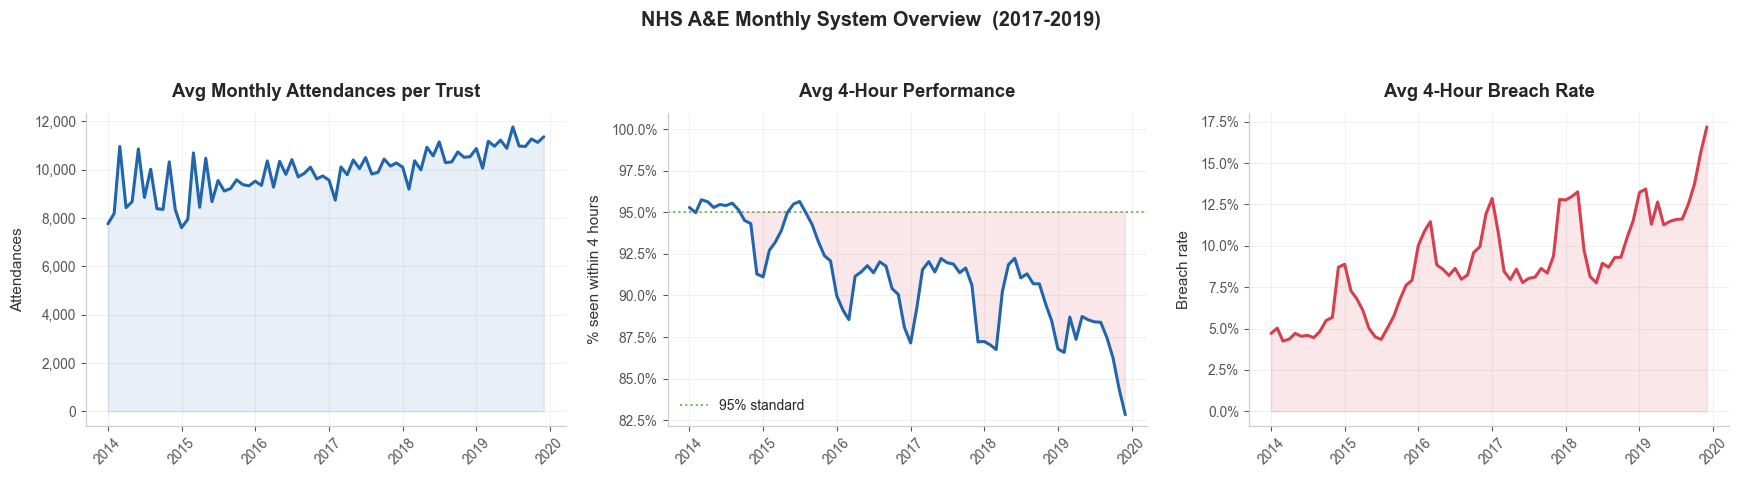

In [5]:
monthly = (
    df_analysis.groupby("month")[
        ["att_total", "pct_4hr_all", "four_hour_breach_rate", "wait_12hr_rate"]
    ]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
fig.suptitle("NHS A&E Monthly System Overview  (2017-2019)",
             fontsize=13, fontweight="bold", y=1.03)

ax = axes[0]
ax.fill_between(monthly["month"], monthly["att_total"], alpha=0.1, color=C_BLUE)
ax.plot(monthly["month"], monthly["att_total"], color=C_BLUE)
ax.set_title("Avg Monthly Attendances per Trust")
ax.set_ylabel("Attendances")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

ax = axes[1]
ax.axhline(0.95, color=C_GREEN, linestyle=":", linewidth=1.3, alpha=0.8, label="95% standard")
ax.fill_between(
    monthly["month"], monthly["pct_4hr_all"], 0.95,
    where=monthly["pct_4hr_all"] < 0.95,
    interpolate=True, alpha=0.12, color=C_RED,
)
ax.plot(monthly["month"], monthly["pct_4hr_all"], color=C_BLUE)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_ylim(top=1.01)
ax.set_title("Avg 4-Hour Performance")
ax.set_ylabel("% seen within 4 hours")
ax.legend(loc="lower left")

ax = axes[2]
ax.fill_between(monthly["month"], monthly["four_hour_breach_rate"], alpha=0.12, color=C_RED)
ax.plot(monthly["month"], monthly["four_hour_breach_rate"], color=C_RED)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title("Avg 4-Hour Breach Rate")
ax.set_ylabel("Breach rate")

for ax in axes:
    ax.tick_params(axis="x", rotation=45)
    ax.set_xlabel("")

fig.tight_layout()
plt.show()

## 3. Data Audit

Verifies data integrity before modelling. The audit checks:

- missing values on the key columns used later in rolling baselines and rate calculations;
- impossible performance values outside `[0, 1]`, which would indicate a scaling error;
- panel balance, because short provider series cannot support stable lagged baselines;
- the largest providers by attendance, mainly to confirm that the England aggregate row has been removed.


In [6]:
print("=== Missing values ===")
print(df_analysis[
    ["provider_code", "provider_name", "month",
     "att_total", "pct_4hr_all", "emerg_adm_total", "wait_12hr_dta"]
].isna().sum())

print("\n=== Impossible 4-hour performance values (outside [0, 1]) ===")
bad = df_analysis[(df_analysis["pct_4hr_all"] < 0) | (df_analysis["pct_4hr_all"] > 1)]
print(f"Count: {len(bad)}")
if len(bad):
    print(bad[["provider_code", "provider_name", "month", "pct_4hr_all"]].head())

print("\n=== Panel balance: months observed per provider ===")
print(df_analysis.groupby("provider_code")["month"].nunique().describe().round(1))

print("\n=== Top 10 providers by avg monthly attendances ===")
print(
    df_analysis.groupby(["provider_code", "provider_name"])["att_total"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
    .to_string(index=False)
)

=== Missing values ===
provider_code      0
provider_name      0
month              0
att_total          0
pct_4hr_all        0
emerg_adm_total    0
wait_12hr_dta      0
dtype: int64

=== Impossible 4-hour performance values (outside [0, 1]) ===
Count: 0

=== Panel balance: months observed per provider ===
count    221.0
mean      60.2
std       20.7
min        3.0
25%       63.0
50%       72.0
75%       72.0
max       72.0
Name: month, dtype: float64

=== Top 10 providers by avg monthly attendances ===
provider_code                                                 provider_name    att_total
          R1H                                        Barts Health NHS Trust 39872.166667
          R0A                    Manchester University NHS Foundation Trust 34669.592593
          R1K             London North West University Healthcare NHS Trust 29258.575758
          RW6                             Pennine Acute Hospitals NHS Trust 28934.430556
          R1K                        London No

## 4. Shock Detection

Defines which provider-months represent a genuine demand shock.

**Why a seasonal z-score?**  
The naive approach - z-score against a trailing 12-month rolling mean - confounds seasons. A July baseline built from the prior 12 months contains mostly low-attendance winter months, making a normal summer peak look like a shock (~127 false shocks in March 2016 were traced to this). Instead, each month is compared only to the same calendar month in prior years: July vs prior Julys, January vs prior Januaries. This is equivalent to including calendar-month fixed effects and eliminates seasonal confounding entirely.

**Merger handling:**  
NHS trust mergers create discontinuous attendance jumps that would corrupt a rolling baseline. Two sources of splits are used:
- *Name-change detection* in the panel itself (`series_id` suffix incremented when `provider_name` changes for the same code).
- *Official NHS succession dates* from `succ.csv`, which catches silent absorptions where the absorbing trust keeps its name but attendance jumps (e.g. RRK/Birmingham absorbing Heart of England in April 2018).

Each resulting `series_id` gets its own independent baseline.

**Structural breaks** (z > 10) are excluded from the shock flag - these are merger artefacts, not genuine demand events.

**Threshold:** z ≥ 2.0, requiring ≥ 3 prior same-month observations. First valid shock detectable: January 2017 for most trusts.


In [7]:
df_shock = pd.read_csv(ANALYSIS_READY_PATH)
df_shock["month"] = pd.to_datetime(df_shock["month"])

for col in ["att_total", "pct_4hr_all", "emerg_adm_total", "wait_4hr_dta", "wait_12hr_dta"]:
    df_shock[col] = pd.to_numeric(df_shock[col], errors="coerce")

df_shock = df_shock.dropna(subset=["att_total", "pct_4hr_all"]).copy()
df_shock = df_shock[
    (df_shock["provider_code"] != "-") &
    (~df_shock["provider_name"].str.contains("england", case=False, na=False))
].copy()
df_shock = df_shock.sort_values(["provider_code", "month"]).copy()

df_shock["_name_seq"] = df_shock.groupby("provider_code")["provider_name"].transform(
    lambda x: (x != x.shift(1)).cumsum()
)
df_shock["series_id"] = df_shock["provider_code"] + "_s" + df_shock["_name_seq"].astype(str)
df_shock = df_shock.drop(columns=["_name_seq"])
n_splits = (df_shock.groupby("provider_code")["series_id"].nunique() > 1).sum()
succ_raw = pd.read_csv(SUCC_PATH, header=None,
                       names=["predecessor", "successor", "_col2", "eff_date", "flag"])
succ_raw["eff_date"] = pd.to_datetime(succ_raw["eff_date"].astype(str), format="%Y%m%d")

panel_start = df_shock["month"].min()
panel_end   = df_shock["month"].max()
panel_codes = set(df_shock["provider_code"].unique())

succ_events = (
    succ_raw[
        succ_raw["successor"].isin(panel_codes) &
        succ_raw["eff_date"].between(panel_start, panel_end)
    ]
    .groupby("successor")["eff_date"].max()
    .rename("merger_date")
)
df_shock = df_shock.join(succ_events, on="provider_code")

def _resplit_at_merger(grp):
    mdate = grp["merger_date"].iloc[0]
    if pd.isna(mdate):
        return grp
    pre  = grp[grp["month"] <  mdate]
    post = grp[grp["month"] >= mdate]
    if len(pre) == 0 or len(post) == 0:
        return grp
    if pre["series_id"].iloc[-1] == post["series_id"].iloc[0]:
        grp = grp.copy()
        grp.loc[grp["month"] >= mdate, "series_id"] += "_m"
    return grp

df_shock = df_shock.groupby("provider_code", group_keys=False).apply(_resplit_at_merger)
df_shock = df_shock.drop(columns=["merger_date"])

n_splits = (df_shock.groupby("provider_code")["series_id"].nunique() > 1).sum()
print(f"Provider codes split into ≥2 series (name change + succession): {n_splits}")

df_shock["four_hour_breach_rate"] = 1 - df_shock["pct_4hr_all"]
df_shock["admission_rate"]        = df_shock["emerg_adm_total"] / df_shock["att_total"]
df_shock["wait_4hr_rate"]         = df_shock["wait_4hr_dta"]    / df_shock["att_total"]
df_shock["wait_12hr_rate"]        = df_shock["wait_12hr_dta"]   / df_shock["att_total"]

df_shock["month_num"] = df_shock["month"].dt.month

def _seasonal_stats(grp):
    grp = grp.sort_values("month").copy()
    shifted = grp["att_total"].shift(1)
    grp["att_seasonal_mean"] = shifted.expanding(min_periods=3).mean()
    grp["att_seasonal_std"]  = shifted.expanding(min_periods=3).std()
    return grp

df_shock = (
    df_shock
    .groupby(["series_id", "month_num"], group_keys=False)
    .apply(_seasonal_stats)
)

df_shock["demand_ratio"]          = df_shock["att_total"] / df_shock["att_seasonal_mean"]
df_shock["demand_zscore"]         = ((df_shock["att_total"] - df_shock["att_seasonal_mean"])
                                     / df_shock["att_seasonal_std"])
df_shock["demand_zscore_capped"]  = df_shock["demand_zscore"].clip(-5, 5)
df_shock["structural_break_flag"] = df_shock["demand_zscore"] > 10

df_shock["shock_ratio"]  = df_shock["demand_ratio"]  >= RATIO_THRESHOLD
df_shock["shock_zscore"] = df_shock["demand_zscore"] >= ZSCORE_THRESHOLD
df_shock["shock"]        = df_shock["shock_zscore"] & ~df_shock["structural_break_flag"]

df_shock["breach_change"]    = df_shock.groupby("series_id")["four_hour_breach_rate"].diff()
df_shock["perf_change"]      = df_shock.groupby("series_id")["pct_4hr_all"].diff()
df_shock["wait_12hr_change"] = df_shock.groupby("series_id")["wait_12hr_rate"].diff()

df_shock.to_csv(WITH_SHOCKS_PATH, index=False)
print(f"Saved  {WITH_SHOCKS_PATH.name}  |  shape: {df_shock.shape}")

Provider codes split into ≥2 series (name change + succession): 34
Saved  ae_panel_with_shocks.csv  |  shape: (13249, 28)


In [8]:
print(f"Shock share  z-score (z≥{ZSCORE_THRESHOLD}) : {df_shock['shock_zscore'].mean():.1%}  ({int(df_shock['shock_zscore'].sum())} months)")
print(f"Shock share  canonical (excl. breaks): {df_shock['shock'].mean():.1%}  ({int(df_shock['shock'].sum())} months)")
print(f"Shock share  ratio                   : {df_shock['shock_ratio'].mean():.1%}  ({int(df_shock['shock_ratio'].sum())} months)")
print(f"\nDefinition overlap:")
print(pd.crosstab(df_shock["shock_ratio"], df_shock["shock"],
                  rownames=["Ratio shock"], colnames=["Z-score canonical"]))
print(f"\nStructural breaks excluded (z > 10) : {int(df_shock['structural_break_flag'].sum())}")
print(f"Series with ≥1 shock                : {int((df_shock.groupby('series_id')['shock'].sum() > 0).sum())}")

shock_summary = (
    df_shock[df_shock["shock"]]
    .groupby(["provider_code", "provider_name"])
    .agg(
        shock_months       = ("shock", "sum"),
        avg_demand_ratio   = ("demand_ratio", "mean"),
        avg_breach_change  = ("breach_change", "mean"),
        avg_wait_12hr_rate = ("wait_12hr_rate", "mean"),
        avg_attendances    = ("att_total", "mean"),
    )
    .reset_index()
    .sort_values("avg_breach_change", ascending=False)
)
shock_summary.to_csv(SHOCK_SUMMARY_PATH, index=False)

print(f"\nTop 10 fragile trusts during shocks (largest 4-hr breach deterioration):")
print(
    shock_summary[shock_summary["shock_months"] >= 2]
    .head(10)[["provider_name", "shock_months", "avg_demand_ratio", "avg_breach_change"]]
    .to_string(index=False)
)

Shock share  z-score (z≥2.0) : 7.6%  (1003 months)
Shock share  canonical (excl. breaks): 7.0%  (934 months)
Shock share  ratio                   : 11.2%  (1484 months)

Definition overlap:
Z-score canonical  False  True 
Ratio shock                    
False              11424    341
True                 891    593

Structural breaks excluded (z > 10) : 69
Series with ≥1 shock                : 140

Top 10 fragile trusts during shocks (largest 4-hr breach deterioration):
                                                provider_name  shock_months  avg_demand_ratio  avg_breach_change
                            Mid Yorkshire Hospitals NHS Trust             3          1.141829           0.044365
                             East Sussex Healthcare NHS Trust             2          1.164057           0.033867
           Wrightington, Wigan And Leigh NHS Foundation Trust             5          1.409886           0.028319
Norfolk And Norwich University Hospitals NHS Foundation Trust           

> **Seasonal z-score check:** after rerunning this section, shock months should be spread across the calendar rather than concentrated in mechanically high-attendance months. The breach-impact significance test is performed in Section 5, after the rolling expected-breach baseline has been computed.

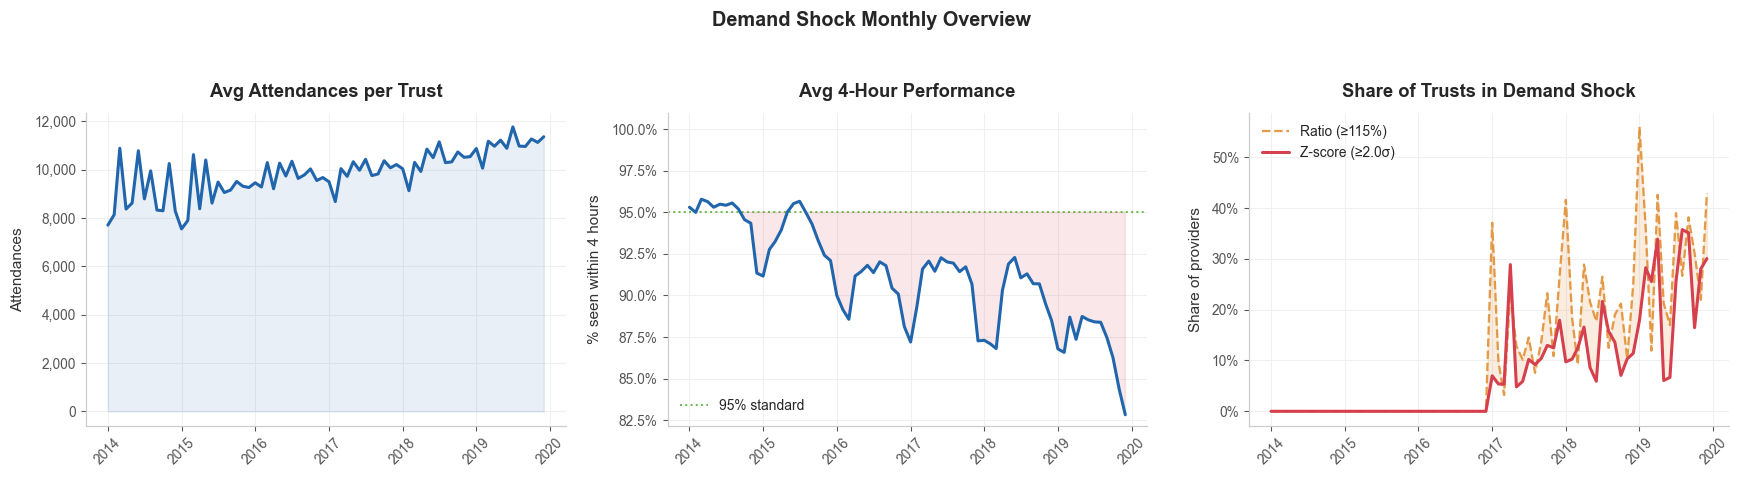

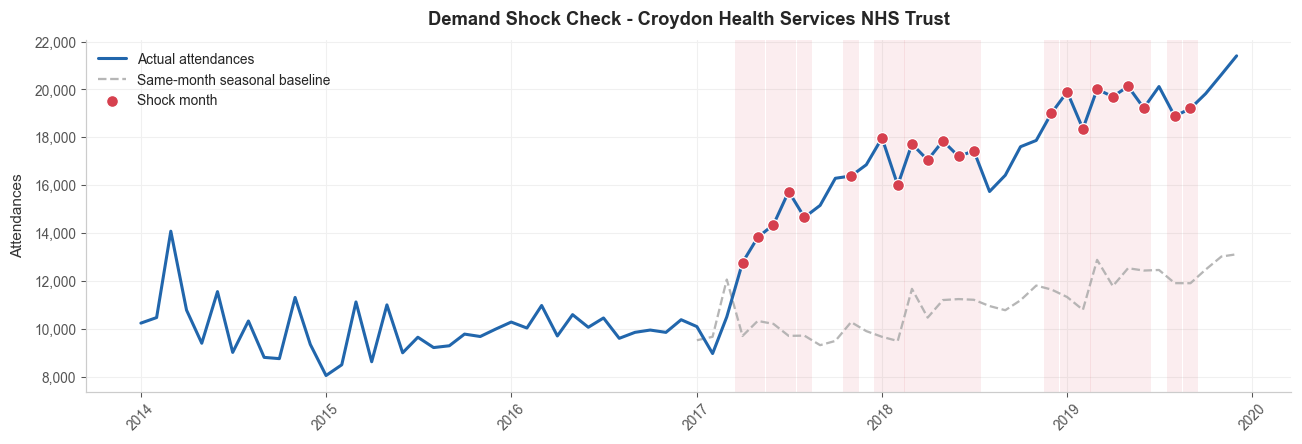

In [9]:
monthly_shock = (
    df_shock.groupby("month")
    .agg(
        avg_att            = ("att_total", "mean"),
        avg_4hr            = ("pct_4hr_all", "mean"),
        shock_ratio_share  = ("shock_ratio", "mean"),
        shock_zscore_share = ("shock_zscore", "mean"),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
fig.suptitle("Demand Shock Monthly Overview", fontsize=13, fontweight="bold", y=1.03)

ax = axes[0]
ax.fill_between(monthly_shock["month"], monthly_shock["avg_att"], alpha=0.1, color=C_BLUE)
ax.plot(monthly_shock["month"], monthly_shock["avg_att"], color=C_BLUE)
ax.set_title("Avg Attendances per Trust")
ax.set_ylabel("Attendances")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

ax = axes[1]
ax.axhline(0.95, color=C_GREEN, linestyle=":", linewidth=1.3, alpha=0.8, label="95% standard")
ax.fill_between(
    monthly_shock["month"], monthly_shock["avg_4hr"], 0.95,
    where=monthly_shock["avg_4hr"] < 0.95,
    interpolate=True, alpha=0.12, color=C_RED,
)
ax.plot(monthly_shock["month"], monthly_shock["avg_4hr"], color=C_BLUE)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_ylim(top=1.01)
ax.set_title("Avg 4-Hour Performance")
ax.set_ylabel("% seen within 4 hours")
ax.legend(loc="lower left")

ax = axes[2]
ax.fill_between(
    monthly_shock["month"],
    monthly_shock["shock_ratio_share"],
    monthly_shock["shock_zscore_share"],
    alpha=0.15, color=C_ORANGE,
)
ax.plot(monthly_shock["month"], monthly_shock["shock_ratio_share"],
        color=C_ORANGE, linewidth=1.5, linestyle="--",
        label=f"Ratio (≥{RATIO_THRESHOLD:.0%})", alpha=0.85)
ax.plot(monthly_shock["month"], monthly_shock["shock_zscore_share"],
        color=C_RED, label=f"Z-score (≥{ZSCORE_THRESHOLD}σ)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title("Share of Trusts in Demand Shock")
ax.set_ylabel("Share of providers")
ax.legend()

for ax in axes:
    ax.tick_params(axis="x", rotation=45)
    ax.set_xlabel("")
fig.tight_layout()
plt.show()

shock_counts = df_shock.groupby("provider_code")["shock"].sum()
if shock_counts.max() > 0:
    top_code   = shock_counts.idxmax()
    sample     = df_shock[df_shock["provider_code"] == top_code].copy()
    shock_rows = sample[sample["shock"]]

    fig, ax = plt.subplots(figsize=(12, 4.2))

    for _, row in shock_rows.iterrows():
        ax.axvspan(
            row["month"] - pd.Timedelta(days=15),
            row["month"] + pd.Timedelta(days=15),
            alpha=0.09, color=C_RED, linewidth=0,
        )

    ax.plot(sample["month"], sample["att_total"],
            color=C_BLUE, label="Actual attendances", zorder=3)
    ax.plot(sample["month"], sample["att_seasonal_mean"],
            color=C_GRAY, linewidth=1.5, linestyle="--",
            label="Same-month seasonal baseline", alpha=0.85, zorder=2)
    ax.scatter(shock_rows["month"], shock_rows["att_total"],
               color=C_RED, zorder=5, label="Shock month",
               s=60, edgecolors="white", linewidth=0.8)

    ax.set_title(f"Demand Shock Check - {sample['provider_name'].iloc[0]}")
    ax.set_ylabel("Attendances")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    ax.legend(loc="upper left")
    ax.tick_params(axis="x", rotation=45)
    ax.set_xlabel("")
    fig.tight_layout()
    plt.show()

## 5. Resilience Scoring

Measures each trust's deterioration above its own expected 4-hour breach rate during shock months.

**Main target:**

`breach_impact = actual_breach_rate − expected_breach_rate`

where `expected_breach_rate` is the trust series' own lagged 12-month rolling mean breach rate. Positive values mean the trust breached more than expected during the shock; negative values mean it performed better than expected.

**Why a rolling breach baseline?** Attendance is strongly seasonal, so shock detection uses same-calendar-month baselines. Breach rate is treated differently: the score asks whether a trust deteriorates relative to its recent normal operating level. A lagged rolling mean captures that recent normal level without leaking the shock month into its own baseline.

**Shrinkage:** raw mean breach impacts are shrunk toward the cross-trust mean:

`shrunk = (n × impact + k × global_mean) / (n + k)`, with `k = 5`.

This reduces over-interpretation of trusts with very few shock months.

**Score direction:** lower shrunk breach impact is better. The score is therefore constructed so that the lowest impact receives 100 and the highest impact receives 0. Evidence strength is tagged by shock count: low (`<3`), medium (`3-5`), high (`≥6`).

**Gating test:** a one-sample t-test checks whether mean breach impact across all shock months is significantly positive before the rankings are treated as substantively meaningful.


In [10]:
from scipy import stats as scipy_stats

df_res = pd.read_csv(WITH_SHOCKS_PATH)
df_res["month"] = pd.to_datetime(df_res["month"])

for col in ["att_total", "pct_4hr_all", "four_hour_breach_rate", "wait_12hr_rate",
            "demand_ratio", "demand_zscore", "demand_zscore_capped", "structural_break_flag"]:
    if col in df_res.columns:
        df_res[col] = pd.to_numeric(df_res[col], errors="coerce")

if "four_hour_breach_rate" not in df_res.columns:
    df_res["four_hour_breach_rate"] = 1 - df_res["pct_4hr_all"]
if "wait_12hr_rate" not in df_res.columns:
    df_res["wait_12hr_rate"] = df_res["wait_12hr_dta"] / df_res["att_total"]

df_res = df_res.sort_values(["series_id", "month"]).copy()

for new_col, src_col in [
    ("expected_breach_rate", "four_hour_breach_rate"),
    ("expected_wait_12hr_rate", "wait_12hr_rate"),
]:
    df_res[new_col] = (
        df_res.groupby("series_id")[src_col]
        .transform(lambda x: x.shift(1).rolling(ROLLING_WINDOW, min_periods=MIN_PERIODS).mean())
    )

df_res["breach_impact"] = df_res["four_hour_breach_rate"] - df_res["expected_breach_rate"]
df_res["wait_12hr_impact"] = df_res["wait_12hr_rate"] - df_res["expected_wait_12hr_rate"]

break_summary = (
    df_res.groupby("series_id")
    .agg(
        structural_break_months=("structural_break_flag", "sum"),
        structural_break_share=("structural_break_flag", "mean"),
    )
    .reset_index()
)

shock_df = df_res[
    as_bool(df_res["shock"]) &
    df_res["breach_impact"].notna()
].copy()

mean_impact = shock_df["breach_impact"].mean()
t_stat, p_val = scipy_stats.ttest_1samp(shock_df["breach_impact"], 0)
ci = scipy_stats.t.interval(
    0.95,
    df=len(shock_df) - 1,
    loc=mean_impact,
    scale=scipy_stats.sem(shock_df["breach_impact"]),
)

print(f"Breach impact gating test  (n={len(shock_df)} shock-months)")
print(f"  Mean : {mean_impact:+.5f} breach-rate units ({mean_impact * 100:+.2f} percentage points)")
print(f"  t={t_stat:.2f},  p={p_val:.4f}")
print(f"  95% CI: ({ci[0]:+.5f}, {ci[1]:+.5f})")
if p_val < 0.05:
    print("  → Mean effect significant: resilience ranking has empirical grounding.")
else:
    print("  → Mean effect is not significant. Interpret trust rankings cautiously.")

trust_res = (
    shock_df.groupby(["series_id", "provider_code", "provider_name"])
    .agg(
        n_shocks=("shock", "sum"),
        mean_breach_impact=("breach_impact", "mean"),
        mean_wait_12hr_impact=("wait_12hr_impact", "mean"),
        mean_breach_during_shock=("four_hour_breach_rate", "mean"),
        mean_expected_breach=("expected_breach_rate", "mean"),
        mean_demand_ratio=("demand_ratio", "mean"),
        mean_demand_zscore=("demand_zscore", "mean"),
        mean_demand_zscore_capped=("demand_zscore_capped", "mean"),
        avg_attendances_during_shock=("att_total", "mean"),
    )
    .reset_index()
    .merge(break_summary, on="series_id", how="left")
)

def shrink(df, col, k=SHRINKAGE_K):
    overall = df[col].mean()
    return (df["n_shocks"] * df[col] + k * overall) / (df["n_shocks"] + k)

def resilience_score_from_impact(s):
    out = pd.Series(np.nan, index=s.index)
    valid = s.notna()
    n = int(valid.sum())
    if n == 0:
        return out
    if n == 1:
        out.loc[valid] = 100.0
        return out
    ranks = s.loc[valid].rank(method="average", ascending=True)
    out.loc[valid] = 100 * (1 - (ranks - 1) / (n - 1))
    return out

trust_res["shrunk_breach_impact"] = shrink(trust_res, "mean_breach_impact")
trust_res["breach_resilience_score"] = resilience_score_from_impact(trust_res["shrunk_breach_impact"])
trust_res["resilience_score"] = trust_res["breach_resilience_score"]

trust_res["evidence_strength"] = pd.cut(
    trust_res["n_shocks"], bins=[0, 2, 5, 100], labels=["low", "medium", "high"]
)
trust_res = trust_res.sort_values("resilience_score", ascending=False)
trust_res.to_csv(RESILIENCE_PATH, index=False)

print(f"\nSaved  {RESILIENCE_PATH.name}  |  {len(trust_res)} trust series scored")
print(f"\nShock count distribution:\n{trust_res['n_shocks'].describe().round(1)}")
print(f"\nTop 10 most resilient:")
print(trust_res[["provider_name", "resilience_score", "n_shocks", "evidence_strength"]].head(10).to_string(index=False))
print(f"\n10 most fragile:")
print(trust_res[["provider_name", "resilience_score", "n_shocks", "evidence_strength"]].tail(10).to_string(index=False))

Breach impact gating test  (n=934 shock-months)
  Mean : +0.01056 breach-rate units (+1.06 percentage points)
  t=8.21,  p=0.0000
  95% CI: (+0.00803, +0.01308)
  → Mean effect significant: resilience ranking has empirical grounding.

Saved  trust_resilience_scores.csv  |  140 trust series scored

Shock count distribution:
count    140.0
mean       6.7
std        4.9
min        1.0
25%        2.0
50%        6.0
75%        9.0
max       22.0
Name: n_shocks, dtype: float64

Top 10 most resilient:
                                                  provider_name  resilience_score  n_shocks evidence_strength
                             Salford Royal NHS Foundation Trust        100.000000         6              high
            Colchester Hospital University NHS Foundation Trust         99.280576        11              high
Basildon And Thurrock University Hospitals NHS Foundation Trust         98.561151         7              high
                                    Medway NHS Foundation Tr

> **Shrinkage effect:** trusts with few shock observations are pulled more strongly toward the cross-trust mean. This prevents one anomalous shock month from dominating the ranking. The plot below shows the raw-to-shrunk movement directly; interpret low-evidence ranks cautiously even after shrinkage.

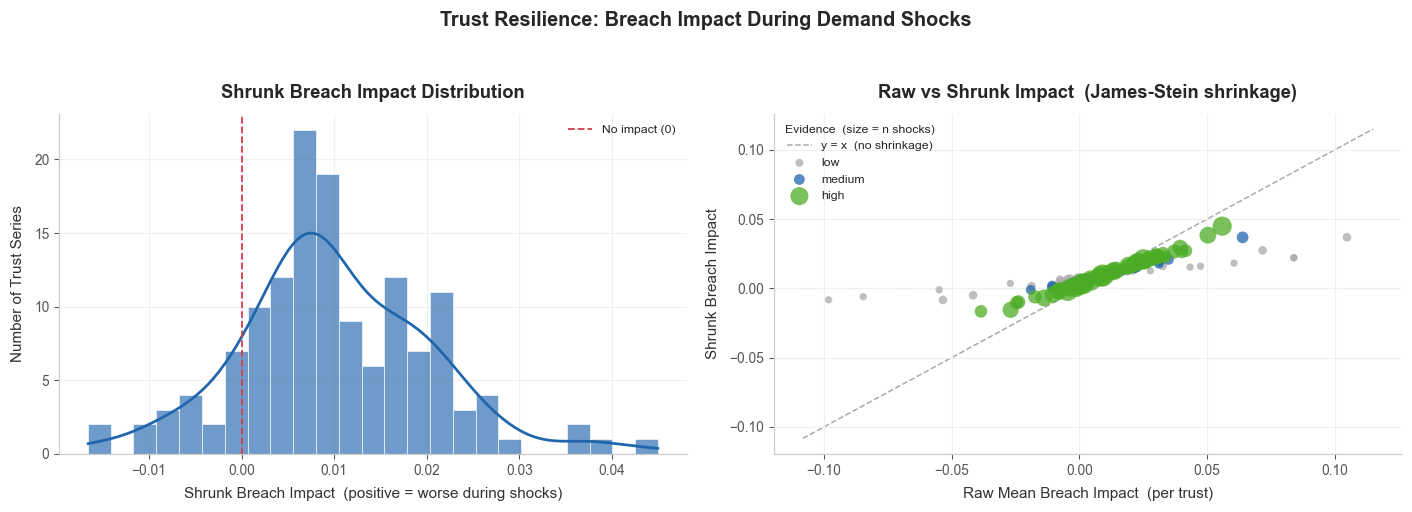

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle("Trust Resilience: Breach Impact During Demand Shocks",
             fontsize=13, fontweight="bold", y=1.03)

ax = axes[0]
sns.histplot(
    trust_res["shrunk_breach_impact"], bins=25, ax=ax,
    color=C_BLUE, alpha=0.65, kde=True,
    line_kws={"linewidth": 1.8, "color": C_BLUE},
    edgecolor="white", linewidth=0.4,
)
ax.axvline(0, color=C_RED, linewidth=1.2, linestyle="--", label="No impact (0)", zorder=5)
ax.set_title("Shrunk Breach Impact Distribution")
ax.set_xlabel("Shrunk Breach Impact  (positive = worse during shocks)")
ax.set_ylabel("Number of Trust Series")
ax.legend(fontsize=8)

ax = axes[1]
lim_vals = pd.concat([trust_res["mean_breach_impact"], trust_res["shrunk_breach_impact"]])
lo, hi   = lim_vals.min(), lim_vals.max()
pad      = (hi - lo) * 0.05
ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad],
        color=C_GRAY, linewidth=1.0, linestyle="--", zorder=0, label="y = x  (no shrinkage)")
ax.axhline(0, color=C_GRAY, linewidth=0.7, linestyle=":", zorder=0)

for ev in ["low", "medium", "high"]:
    grp = trust_res[trust_res["evidence_strength"].astype(str) == ev]
    if len(grp):
        ax.scatter(
            grp["mean_breach_impact"], grp["shrunk_breach_impact"],
            color=EVIDENCE_PALETTE[ev], alpha=0.75,
            s=grp["n_shocks"] * 9 + 14,
            edgecolors="none", label=ev,
        )
ax.set_title("Raw vs Shrunk Impact  (James-Stein shrinkage)")
ax.set_xlabel("Raw Mean Breach Impact  (per trust)")
ax.set_ylabel("Shrunk Breach Impact")
ax.legend(title="Evidence  (size = n shocks)", title_fontsize=8, fontsize=8)

fig.tight_layout()
plt.show()


## 6. Trust Clustering

Groups trusts by their demand-shock response profile using K-means on two features:

| Feature | What it captures |
|---|---|
| `shrunk_breach_impact` | How much worse the trust performed during shocks, after evidence shrinkage |
| `mean_demand_zscore_capped` | The typical intensity of the shocks the trust faced |

**Why only two features?** Trust size, shock frequency, and structural-break share are not clustering features. Earlier versions that included them tended to sort trusts by scale and data-quality artefacts rather than by resilience behaviour.

**k = 3:** the silhouette table is printed in the code cell. If k = 2 remains the numerical peak, k = 3 is still retained only if the third group adds a useful resilient/moderate/fragile interpretation at a small silhouette cost.

**Sample filter:** only medium/high evidence series (`≥3` shock months) with no structural-break months in the full series history are clustered. Low-evidence trusts remain scored, but are excluded from the cluster narrative.


In [12]:
df_clust = pd.read_csv(RESILIENCE_PATH)

df_clust = df_clust[
    df_clust["evidence_strength"].isin(["medium", "high"]) &
    (df_clust["structural_break_share"] == 0)
].copy()

features = [
    "shrunk_breach_impact",
    "mean_demand_zscore_capped",
]
df_clust = df_clust.dropna(subset=features).copy()
X_scaled = StandardScaler().fit_transform(df_clust[features])

print(f"Trust series available for clustering: {len(df_clust)}")

print("\nSilhouette scores (k = 2-6):")
for k in range(2, 7):
    labels = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20).fit_predict(X_scaled)
    print(f"  k={k}: {silhouette_score(X_scaled, labels):.3f}")

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=20)
df_clust["cluster"] = kmeans.fit_predict(X_scaled)

profile_cols = [
    "resilience_score",
    "shrunk_breach_impact",
    "mean_demand_zscore_capped",
    "mean_demand_zscore",
    "avg_attendances_during_shock",
    "n_shocks",
]
cluster_profile = df_clust.groupby("cluster")[profile_cols].mean().round(4)
cluster_profile.insert(0, "n_trusts", df_clust["cluster"].value_counts().sort_index())

print(f"\nCluster profiles (k={N_CLUSTERS}):")
print(cluster_profile.to_string())

n_c         = cluster_profile.shape[0]
impact_rank = cluster_profile["shrunk_breach_impact"].rank().astype(int)
label_map   = {}
for c in cluster_profile.index:
    r = impact_rank[c]
    if   r == 1:   label_map[c] = "resilient"
    elif r == 2:   label_map[c] = "moderate"
    elif r == n_c - 1 and n_c >= 4: label_map[c] = "vulnerable"
    elif r == n_c: label_map[c] = "fragile"
    else:          label_map[c] = "moderate"
df_clust["cluster_label"] = df_clust["cluster"].map(label_map)

df_clust.to_csv(CLUSTERS_PATH, index=False)
print(f"\nSaved  {CLUSTERS_PATH.name}")

for lbl in ["resilient", "moderate", "vulnerable", "fragile"]:
    sub = df_clust[df_clust["cluster_label"] == lbl]
    if len(sub):
        print(f"\nTop 5 {lbl}:")
        print(
            sub.sort_values("resilience_score", ascending=(lbl == "fragile"))
            [["provider_name", "resilience_score", "shrunk_breach_impact", "n_shocks"]]
            .head(5).to_string(index=False)
        )

Trust series available for clustering: 77

Silhouette scores (k = 2-6):
  k=2: 0.415
  k=3: 0.360
  k=4: 0.366
  k=5: 0.359
  k=6: 0.395

Cluster profiles (k=3):
         n_trusts  resilience_score  shrunk_breach_impact  mean_demand_zscore_capped  mean_demand_zscore  avg_attendances_during_shock  n_shocks
cluster                                                                                                                                         
0              16           80.4406                0.0012                     3.4741              3.7633                    12824.4143    9.6250
1              31           56.5096                0.0076                     2.6903              2.7102                    11605.3333    6.8710
2              30           14.7002                0.0219                     2.8304              2.9338                    11968.1270    8.6667

Saved  trust_resilience_clusters.csv

Top 5 resilient:
                                           provider_name 

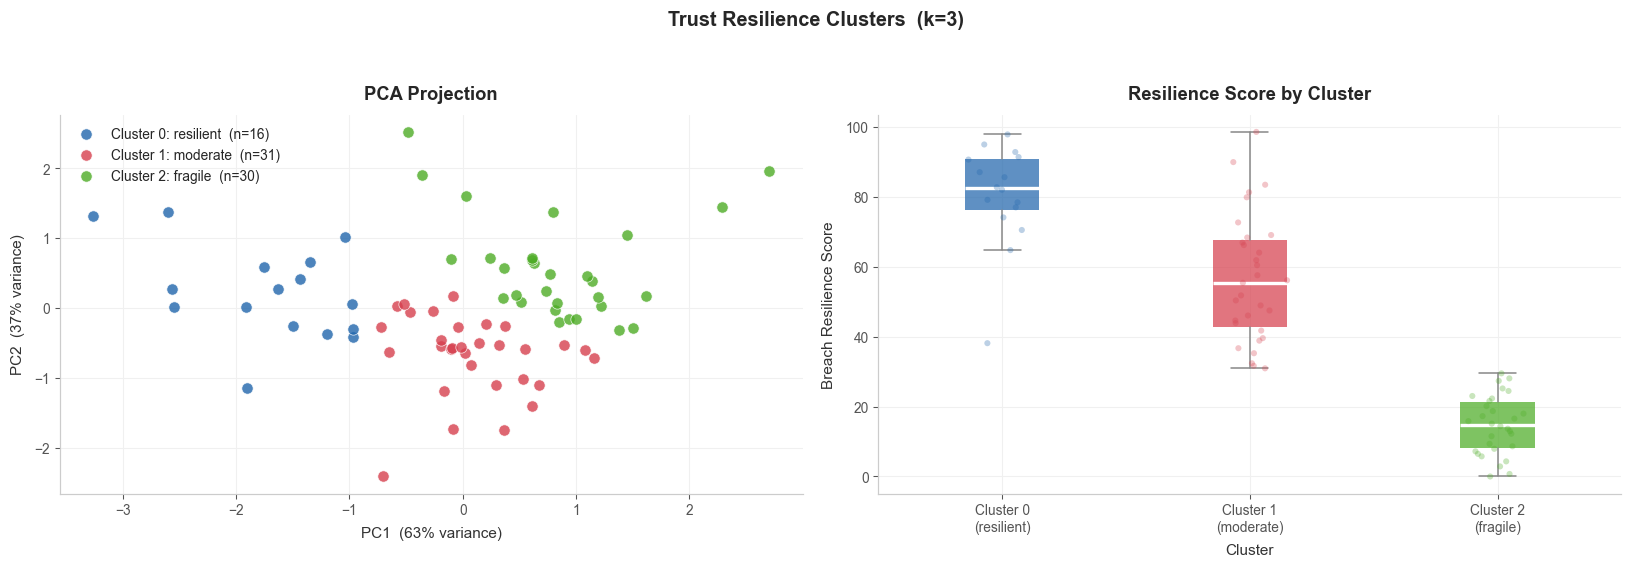

In [13]:
pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)
df_clust["pca1"] = coords[:, 0]
df_clust["pca2"] = coords[:, 1]

cluster_ids    = sorted(df_clust["cluster"].unique())
cluster_colors = CLUSTER_COLORS[:len(cluster_ids)]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(f"Trust Resilience Clusters  (k={N_CLUSTERS})", fontsize=13, fontweight="bold", y=1.03)

ax = axes[0]
for c in cluster_ids:
    sub   = df_clust[df_clust["cluster"] == c]
    label = sub["cluster_label"].iloc[0]
    ax.scatter(
        sub["pca1"], sub["pca2"],
        label=f"Cluster {c}: {label}  (n={len(sub)})",
        color=cluster_colors[c], alpha=0.8,
        edgecolors="white", linewidth=0.5, s=55,
    )
ax.set_title("PCA Projection")
ax.set_xlabel(f"PC1  ({pca.explained_variance_ratio_[0]:.0%} variance)")
ax.set_ylabel(f"PC2  ({pca.explained_variance_ratio_[1]:.0%} variance)")
ax.legend(fontsize=9)

ax = axes[1]
cluster_data = [df_clust[df_clust["cluster"] == c]["resilience_score"].values for c in cluster_ids]
tick_labels  = [
    f"Cluster {c}\n({df_clust[df_clust['cluster'] == c]['cluster_label'].iloc[0]})"
    for c in cluster_ids
]

bp = ax.boxplot(
    cluster_data, patch_artist=True,
    medianprops=dict(color="white", linewidth=2.2),
    whiskerprops=dict(linewidth=1.0, color="#888888"),
    capprops=dict(linewidth=1.0, color="#888888"),
    flierprops=dict(marker="o", markersize=3, alpha=0.35, markeredgewidth=0),
    boxprops=dict(linewidth=0),
)
for patch, c in zip(bp["boxes"], cluster_ids):
    patch.set_facecolor(cluster_colors[c])
    patch.set_alpha(0.72)

rng = np.random.default_rng(42)
for i, c in enumerate(cluster_ids):
    y = df_clust[df_clust["cluster"] == c]["resilience_score"].values
    x = rng.normal(i + 1, 0.07, size=len(y))
    ax.scatter(x, y, color=cluster_colors[c], alpha=0.30, s=16, edgecolors="none", zorder=3)

ax.set_title("Resilience Score by Cluster")
ax.set_xlabel("Cluster")
ax.set_ylabel("Breach Resilience Score")
ax.set_xticklabels(tick_labels)

fig.tight_layout()
plt.show()

## 7. Trust Heterogeneity (ICC)

Before drawing conclusions from the clustering, we test whether trusts are structurally different in their breach rates rather than randomly variable around a common mean.

An **Intraclass Correlation Coefficient (ICC)** quantifies the share of variance attributable to persistent trust-level differences:

$$	ext{ICC} = 
rac{\sigma^2_u}{\sigma^2_u + \sigma^2_e}$$

where $\sigma^2_u$ is the between-trust variance and $\sigma^2_e$ is the residual within-trust variance.

- **ICC near 1** means persistent trust-level differences dominate.
- **ICC near 0** means providers are closer to random draws from a common distribution.

A high ICC supports trust-level ranking and clustering because it shows that provider identity carries substantial information about breach-rate behaviour.


In [14]:
import statsmodels.formula.api as smf
import warnings as _warn

df_icc = pd.read_csv(WITH_SHOCKS_PATH)
df_icc = df_icc.dropna(subset=["four_hour_breach_rate", "series_id"])
df_icc = df_icc[~as_bool(df_icc["structural_break_flag"])]

df_res_list = pd.read_csv(RESILIENCE_PATH)["series_id"]
df_icc = df_icc[df_icc["series_id"].isin(df_res_list)]

print(f"Observations: {len(df_icc)}   Trust series: {df_icc['series_id'].nunique()}")

with _warn.catch_warnings():
    _warn.simplefilter("ignore")
    icc_model  = smf.mixedlm("four_hour_breach_rate ~ 1", df_icc, groups=df_icc["series_id"])
    icc_result = icc_model.fit(reml=True, method="powell")

var_u = float(icc_result.cov_re.iloc[0, 0])
var_e = float(icc_result.scale)
icc   = var_u / (var_u + var_e)

print(f"\nBetween-trust variance  σ²_u = {var_u:.5f}")
print(f"Residual variance       σ²_e = {var_e:.5f}")
print(f"ICC                         = {icc:.3f}")
print()
print(f"Interpretation: {icc:.0%} of the variance in monthly breach rate is explained")
print(f"by which trust an observation belongs to - persistent structural differences")
print(f"that no amount of time-level smoothing can remove.")
print(f"This validates the trust-level resilience analysis: trusts are not exchangeable;")
print(f"their breach trajectories are largely determined by trust-level characteristics.")

Observations: 9494   Trust series: 140

Between-trust variance  σ²_u = 0.00354
Residual variance       σ²_e = 0.00244
ICC                         = 0.592

Interpretation: 59% of the variance in monthly breach rate is explained
by which trust an observation belongs to - persistent structural differences
that no amount of time-level smoothing can remove.
This validates the trust-level resilience analysis: trusts are not exchangeable;
their breach trajectories are largely determined by trust-level characteristics.


> **ICC ≈ 0.59:** roughly 59 % of the variance in monthly breach rates is attributable to persistent trust-level characteristics - not to time, season, or demand shocks. The residual 41 % is within-trust variation over time. An ICC this large strongly justifies a trust-level analysis: the decision to rank and cluster trusts rather than pool them is supported by the data. (The boundary warning from statsmodels is expected when σ²_u >> σ²_e and does not invalidate the result - all optimisation methods agree on the same estimate.)

## 8. Cluster Stability

K-means is a random-start algorithm - different initialisations can produce different solutions. The **Adjusted Rand Index (ARI)** measures agreement between two cluster labellings, adjusted for chance:

- **ARI = 1.0** → identical cluster assignments  
- **ARI = 0.0** → no better agreement than random  

We run k=3 clustering 30 times with different random seeds and compute ARI across all \(\binom{30}{2} = 435\) pairs. High mean ARI confirms the three-cluster structure is stable and not an artefact of the random initialisation.

Pairwise ARI across 30 bootstrap seeds  (k=3)
  Mean ARI = 0.986   Min = 0.933   Max = 1.000

Strong cluster stability: the k=3 solution is consistent across random starts.


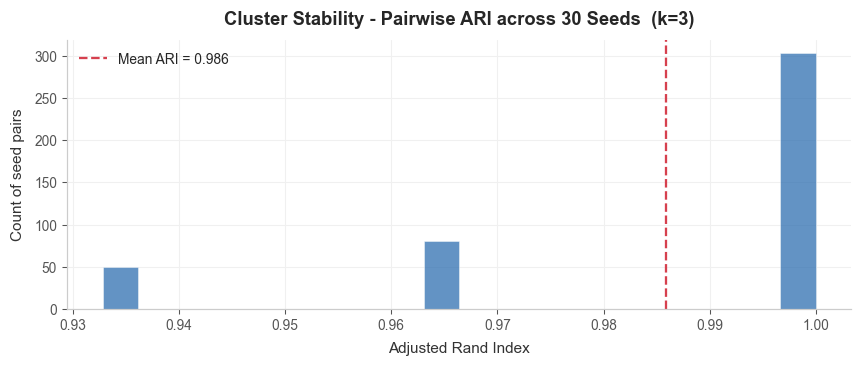

In [15]:
from sklearn.metrics import adjusted_rand_score

n_boot      = 30
boot_labels = [
    KMeans(n_clusters=N_CLUSTERS, random_state=s, n_init=10).fit_predict(X_scaled)
    for s in range(n_boot)
]

ari_pairs = [
    adjusted_rand_score(boot_labels[i], boot_labels[j])
    for i in range(n_boot) for j in range(i + 1, n_boot)
]

mean_ari = float(np.mean(ari_pairs))
print(f"Pairwise ARI across {n_boot} bootstrap seeds  (k={N_CLUSTERS})")
print(f"  Mean ARI = {mean_ari:.3f}   Min = {min(ari_pairs):.3f}   Max = {max(ari_pairs):.3f}")
print()
if mean_ari >= 0.85:
    print("Strong cluster stability: the k=3 solution is consistent across random starts.")
elif mean_ari >= 0.60:
    print("Moderate cluster stability: the grouping is broadly reproducible.")
else:
    print("Low cluster stability: the k=3 solution is sensitive to initialisation.")

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(ari_pairs, bins=20, color=C_BLUE, alpha=0.70, edgecolor="white", linewidth=0.4)
ax.axvline(mean_ari, color=C_RED, linestyle="--", linewidth=1.5,
           label=f"Mean ARI = {mean_ari:.3f}")
ax.set_title(f"Cluster Stability - Pairwise ARI across {n_boot} Seeds  (k={N_CLUSTERS})")
ax.set_xlabel("Adjusted Rand Index")
ax.set_ylabel("Count of seed pairs")
ax.legend()
fig.tight_layout()
plt.show()

## 9. Shock Threshold Robustness

The canonical shock threshold is z ≥ 2.0. This section tests whether trust rankings are sensitive to that choice by recomputing the same rolling-baseline breach-impact ranking at three thresholds.

| Threshold | Interpretation |
|---|---|
| z ≥ 1.0 | Mildly above seasonal attendance baseline |
| z ≥ 1.5 | Clearly above seasonal attendance baseline |
| z ≥ 2.0 | Strong demand shock; used as the main definition |

The comparison uses Spearman rank correlation across trust series observed at all three thresholds. High correlations indicate that the ranking is not driven by an arbitrary cutoff.


Trust series with ≥2 shock months at all three thresholds: 102

Spearman rank correlations:
  z≥1.0 vs z≥1.5 :  ρ = 0.906   p = 0.0000   n=102
  z≥1.0 vs z≥2.0 :  ρ = 0.838   p = 0.0000   n=102
  z≥1.5 vs z≥2.0 :  ρ = 0.897   p = 0.0000   n=102


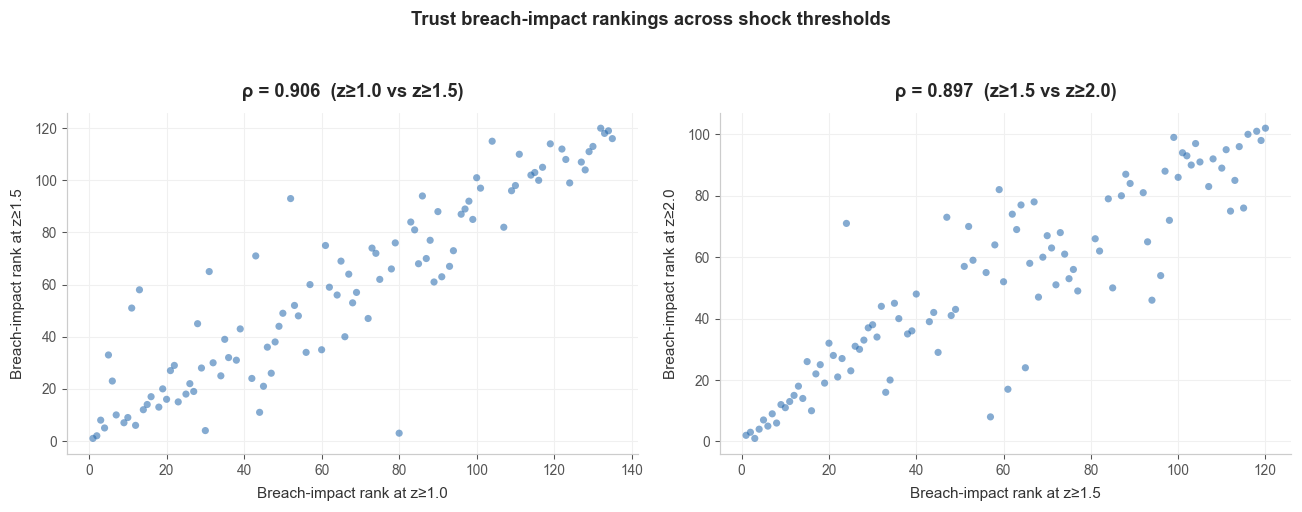

In [16]:
from scipy.stats import spearmanr

df_sens = pd.read_csv(WITH_SHOCKS_PATH)
df_sens["month"] = pd.to_datetime(df_sens["month"])
df_sens = df_sens.sort_values(["series_id", "month"]).copy()

df_sens = df_sens.dropna(subset=["four_hour_breach_rate", "demand_zscore"])
df_sens["expected_breach_rate"] = (
    df_sens.groupby("series_id")["four_hour_breach_rate"]
    .transform(lambda x: x.shift(1).rolling(ROLLING_WINDOW, min_periods=MIN_PERIODS).mean())
)
df_sens["breach_impact"] = df_sens["four_hour_breach_rate"] - df_sens["expected_breach_rate"]
df_sens = df_sens[
    (~as_bool(df_sens["structural_break_flag"])) &
    df_sens["breach_impact"].notna()
].copy()

thresholds = [1.0, 1.5, 2.0]
rank_map = {}

for z in thresholds:
    sub = df_sens[df_sens["demand_zscore"] >= z].copy()
    agg = (
        sub.groupby("series_id")
        .agg(n_shocks=("breach_impact", "size"), mean_breach_impact=("breach_impact", "mean"))
    )
    agg = agg[agg["n_shocks"] >= 2].copy()
    overall = agg["mean_breach_impact"].mean()
    agg["shrunk_breach_impact"] = (
        agg["n_shocks"] * agg["mean_breach_impact"] + SHRINKAGE_K * overall
    ) / (agg["n_shocks"] + SHRINKAGE_K)
    rank_map[z] = agg["shrunk_breach_impact"].rank(ascending=True)

rank_df = pd.DataFrame({f"z≥{z}": s for z, s in rank_map.items()}).dropna()
n_common = len(rank_df)
print(f"Trust series with ≥2 shock months at all three thresholds: {n_common}")
print()
print("Spearman rank correlations:")
for i, z1 in enumerate(thresholds):
    for z2 in thresholds[i + 1:]:
        rho, pval = spearmanr(rank_df[f"z≥{z1}"], rank_df[f"z≥{z2}"])
        print(f"  z≥{z1:.1f} vs z≥{z2:.1f} :  ρ = {rho:.3f}   p = {pval:.4f}   n={n_common}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fig.suptitle("Trust breach-impact rankings across shock thresholds",
             fontsize=12, fontweight="bold", y=1.03)

pairs = [(1.0, 1.5), (1.5, 2.0)]
for ax, (z1, z2) in zip(axes, pairs):
    ax.scatter(rank_df[f"z≥{z1}"], rank_df[f"z≥{z2}"],
               color=C_BLUE, alpha=0.55, s=22, edgecolors="none")
    rho, _ = spearmanr(rank_df[f"z≥{z1}"], rank_df[f"z≥{z2}"])
    ax.set_xlabel(f"Breach-impact rank at z≥{z1}")
    ax.set_ylabel(f"Breach-impact rank at z≥{z2}")
    ax.set_title(f"ρ = {rho:.3f}  (z≥{z1} vs z≥{z2})")

fig.tight_layout()
plt.show()


> **Robustness interpretation:** use the printed Spearman correlations to assess sensitivity. Strong positive correlations mean the same trusts remain relatively resilient or fragile under alternative shock cutoffs. Lower correlations, especially between z≥1.0 and z≥2.0, would indicate that mild demand increases and severe shocks are not measuring exactly the same operational phenomenon.

## 10. Geographic Distribution of Resilience Clusters

Mapping the clusters geographically reveals whether trust resilience is spatially concentrated - for example, whether fragile trusts cluster in particular regions of England. Coordinates are approximate trust-site centroids sourced from the NHS ODS code list.

In [17]:
import folium, time, requests

ODS_URL       = "https://directory.spineservices.nhs.uk/ORD/2-0-0/organisations"
POSTCODES_URL = "https://api.postcodes.io/postcodes"
COORDS_CACHE  = DATA_DIR / "trust_coords.csv"

df_map = pd.read_csv(CLUSTERS_PATH)
codes  = df_map["provider_code"].tolist()

if COORDS_CACHE.exists():
    cache      = pd.read_csv(COORDS_CACHE).set_index("provider_code")
    code_coords = {c: (row["lat"], row["lon"]) for c, row in cache.iterrows() if c in codes}
    print(f"Loaded {len(code_coords)} coordinates from cache ({COORDS_CACHE.name})")
else:
    print("Cache not found - fetching from NHS ODS API...")
    postcodes = {}
    for code in codes:
        try:
            r = requests.get(f"{ODS_URL}/{code}", timeout=8)
            if r.status_code == 200:
                loc = r.json()["Organisation"]["GeoLoc"]["Location"]
                pc  = loc.get("PostCode", "").strip()
                if pc:
                    postcodes[code] = pc
        except Exception:
            pass
        time.sleep(0.08)

    pc_list      = list(set(postcodes.values()))
    pc_to_coords = {}
    for i in range(0, len(pc_list), 100):
        chunk = pc_list[i:i+100]
        r = requests.post(POSTCODES_URL, json={"postcodes": chunk}, timeout=15)
        for item in r.json()["result"]:
            if item["result"]:
                res = item["result"]
                pc_to_coords[item["query"]] = (res["latitude"], res["longitude"])

    code_coords = {c: pc_to_coords[pc] for c, pc in postcodes.items() if pc in pc_to_coords}

    rows = [{"provider_code": c, "postcode": postcodes.get(c, ""),
             "lat": code_coords[c][0], "lon": code_coords[c][1]}
            for c in code_coords]
    pd.DataFrame(rows).to_csv(COORDS_CACHE, index=False)
    print(f"Fetched {len(code_coords)} coordinates - cached to {COORDS_CACHE.name}")

LABEL_COLORS = {
    "resilient": "#2166AC",
    "moderate":  "#E08B2C",
    "fragile":   "#D6404E",
}

df_map["coords"] = df_map["provider_code"].map(code_coords)
df_mapped = df_map.dropna(subset=["coords"]).copy()
print(f"Trusts on map: {len(df_mapped)}")
print(df_mapped["cluster_label"].value_counts())

m = folium.Map(location=[52.5, -1.5], zoom_start=6, tiles="CartoDB positron")

for _, row in df_mapped.iterrows():
    lat, lon = row["coords"]
    colour   = LABEL_COLORS.get(row["cluster_label"], "#888888")
    tooltip  = (
        f"<b>{row['provider_name']}</b><br>"
        f"Cluster: <b>{row['cluster_label']}</b><br>"
        f"Resilience score: {row['resilience_score']:.1f}<br>"
        f"Breach impact: {row['shrunk_breach_impact']:.4f}<br>"
        f"Shocks: {int(row['n_shocks'])}"
    )
    folium.CircleMarker(
        location=[lat, lon],
        radius=7,
        color="white", weight=1,
        fill=True, fill_color=colour, fill_opacity=0.80,
        tooltip=folium.Tooltip(tooltip, sticky=True),
    ).add_to(m)

legend_html = """
<div style="position:fixed;bottom:30px;left:30px;z-index:1000;
            background:white;padding:10px 14px;border-radius:6px;
            box-shadow:0 1px 5px rgba(0,0,0,.3);font-size:13px;">
  <b>Resilience cluster</b><br>
  <span style="color:#2166AC;">&#9679;</span> Resilient<br>
  <span style="color:#E08B2C;">&#9679;</span> Moderate<br>
  <span style="color:#D6404E;">&#9679;</span> Fragile
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

map_path = BASE_DIR / "trust_resilience_map.html"
m.save(str(map_path))
print(f"\nSaved  {map_path.name}")

m

Loaded 77 coordinates from cache (trust_coords.csv)
Trusts on map: 77
cluster_label
moderate     31
fragile      30
resilient    16
Name: count, dtype: int64

Saved  trust_resilience_map.html


## 10b. Graph Neural Network - Spatial Resilience Classification

**Research question:** Does geographic neighbourhood carry additional predictive signal for resilience cluster membership beyond the features themselves?

A 2-layer Graph Convolutional Network (GCN; Kipf & Welling 2017) classifies each trust into its resilience cluster using `shrunk_breach_impact` and `mean_demand_zscore_capped` as node features. Edges connect each trust to its **k = 5 geographically nearest neighbours** (Euclidean distance on lat/lon). The symmetric normalised adjacency Â = D⁻½(A+I)D⁻½ propagates each node’s features across its spatial neighbourhood before classification.

Comparison to a logistic regression baseline (same features, no graph) shows whether adding spatial structure helps.

Model                               Val accuracy
────────────────────────────────────────────────
Logistic regression (no graph)      95.8%
GCN  (k=5 geographic neighbours)    54.2%

GCN classification report (val):
              precision    recall  f1-score   support

   resilient       0.50      0.40      0.44         5
    moderate       0.67      0.60      0.63        10
     fragile       0.45      0.56      0.50         9

    accuracy                           0.54        24
   macro avg       0.54      0.52      0.53        24
weighted avg       0.55      0.54      0.54        24



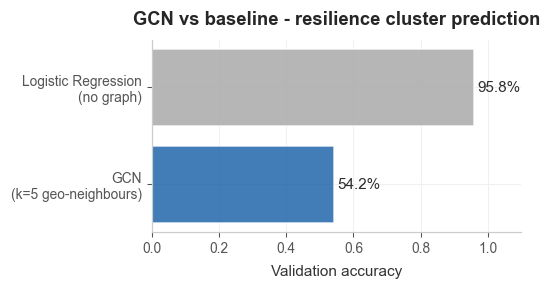

Saved  trust_gnn_map.html


In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.spatial.distance import cdist
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, classification_report

LABEL_MAP = {"resilient": 0, "moderate": 1, "fragile": 2}
INV_LABEL  = {0: "resilient", 1: "moderate", 2: "fragile"}
K_NEIGH    = 5

df_gnn = df_mapped.copy()
df_gnn["lat"] = df_gnn["coords"].apply(lambda c: c[0])
df_gnn["lon"] = df_gnn["coords"].apply(lambda c: c[1])
df_gnn = df_gnn.dropna(subset=["shrunk_breach_impact", "mean_demand_zscore_capped"]).reset_index(drop=True)

n    = len(df_gnn)
y_np = np.array([LABEL_MAP[l] for l in df_gnn["cluster_label"]])

feat_cols = ["shrunk_breach_impact", "mean_demand_zscore_capped"]
X_raw     = df_gnn[feat_cols].values.astype(float)
X_np      = (X_raw - X_raw.mean(0)) / (X_raw.std(0) + 1e-8)

dist_mat = cdist(df_gnn[["lat", "lon"]].values, df_gnn[["lat", "lon"]].values)
adj      = np.zeros((n, n))
for i in range(n):
    nns = np.argsort(dist_mat[i])[1 : K_NEIGH + 1]
    adj[i, nns] = 1
    adj[nns, i] = 1

A_hat      = adj + np.eye(n)
D_inv_sqrt = np.diag(1.0 / np.sqrt(A_hat.sum(1)))
A_norm     = D_inv_sqrt @ A_hat @ D_inv_sqrt

X_t = torch.tensor(X_np,   dtype=torch.float32)
A_t = torch.tensor(A_norm, dtype=torch.float32)
y_t = torch.tensor(y_np,   dtype=torch.long)

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=RANDOM_STATE)
train_idx, val_idx = next(sss.split(X_np, y_np))
train_mask = torch.zeros(n, dtype=torch.bool);  train_mask[train_idx] = True
val_mask   = torch.zeros(n, dtype=torch.bool);  val_mask[val_idx]     = True

class GCN(nn.Module):
    def __init__(self, in_dim, hidden, out_dim):
        super().__init__()
        self.W1 = nn.Linear(in_dim, hidden, bias=False)
        self.W2 = nn.Linear(hidden, out_dim, bias=False)

    def forward(self, A, X):
        h = F.relu(A @ self.W1(X))
        return A @ self.W2(h)

torch.manual_seed(RANDOM_STATE)
gcn = GCN(in_dim=2, hidden=16, out_dim=3)
opt = torch.optim.Adam(gcn.parameters(), lr=0.01, weight_decay=5e-4)

for _ in range(300):
    gcn.train()
    opt.zero_grad()
    F.cross_entropy(gcn(A_t, X_t)[train_mask], y_t[train_mask]).backward()
    opt.step()

gcn.eval()
with torch.no_grad():
    preds = gcn(A_t, X_t).argmax(1).numpy()

lr_clf   = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_clf.fit(X_np[train_idx], y_np[train_idx])
lr_preds = lr_clf.predict(X_np)

gcn_val = accuracy_score(y_np[val_idx], preds[val_idx])
lr_val  = accuracy_score(y_np[val_idx], lr_preds[val_idx])

print(f"{'Model':<34}  Val accuracy")
print("─" * 48)
print(f"{'Logistic regression (no graph)':<34}  {lr_val:.1%}")
print(f"{'GCN  (k=' + str(K_NEIGH) + ' geographic neighbours)':<34}  {gcn_val:.1%}")
print(f"\nGCN classification report (val):")
print(classification_report(y_np[val_idx], preds[val_idx],
                              target_names=["resilient", "moderate", "fragile"]))

fig, ax = plt.subplots(figsize=(5, 2.8))
bar_labels = ["Logistic Regression\n(no graph)", f"GCN\n(k={K_NEIGH} geo-neighbours)"]
bar_accs   = [lr_val, gcn_val]
bars = ax.barh(bar_labels, bar_accs, color=[C_GRAY, C_BLUE], alpha=0.85)
ax.set_xlim(0, 1.10)
ax.set_xlabel("Validation accuracy")
ax.set_title("GCN vs baseline - resilience cluster prediction")
for bar, acc in zip(bars, bar_accs):
    ax.text(acc + 0.01, bar.get_y() + bar.get_height() / 2,
            f"{acc:.1%}", va="center", fontsize=10, color=C_DARK)
ax.invert_yaxis()
fig.tight_layout()
plt.show()

df_gnn["gnn_label"]   = [INV_LABEL[int(p)] for p in preds]
df_gnn["gnn_correct"] = df_gnn["gnn_label"] == df_gnn["cluster_label"]

m_gnn = folium.Map(location=[52.5, -1.5], zoom_start=6, tiles="CartoDB positron")

for _, row in df_gnn.iterrows():
    lat, lon = row["coords"]
    colour   = LABEL_COLORS.get(row["gnn_label"], "#888888")
    bw       = 1 if row["gnn_correct"] else 3
    bc       = "white" if row["gnn_correct"] else "#111111"
    tip = (
        f"<b>{row['provider_name']}</b><br>"
        f"Actual: <b>{row['cluster_label']}</b><br>"
        f"GCN predicted: <b>{row['gnn_label']}</b><br>"
        f"{'\u2713 Correct' if row['gnn_correct'] else '\u2717 Misclassified'}"
    )
    folium.CircleMarker(
        location=[lat, lon], radius=7,
        color=bc, weight=bw,
        fill=True, fill_color=colour, fill_opacity=0.80,
        tooltip=folium.Tooltip(tip, sticky=True),
    ).add_to(m_gnn)

gnn_legend = """
<div style="position:fixed;bottom:30px;left:30px;z-index:1000;
            background:white;padding:10px 14px;border-radius:6px;
            box-shadow:0 1px 5px rgba(0,0,0,.3);font-size:13px;">
  <b>GCN predicted cluster</b><br>
  <span style="color:#2166AC;">&#9679;</span> Resilient<br>
  <span style="color:#E08B2C;">&#9679;</span> Moderate<br>
  <span style="color:#D6404E;">&#9679;</span> Fragile<br>
  <hr style="margin:6px 0">
  <span style="font-size:11px;color:#555;">Thick black border = misclassified</span>
</div>
"""
m_gnn.get_root().html.add_child(folium.Element(gnn_legend))

gnn_map_path = BASE_DIR / "trust_gnn_map.html"
m_gnn.save(str(gnn_map_path))
print(f"Saved  {gnn_map_path.name}")
m_gnn

> **GNN finding:** compare the validation accuracy printed above. In the reviewed run, logistic regression substantially outperformed the GCN, so the correct conclusion is not that the models are comparable. The safer interpretation is that this k-nearest-neighbour geographic graph provides no evidence of added spatial predictive value beyond the two resilience features. The GCN is retained as a negative result: geographic proximity, as encoded here, does not appear to explain resilience cluster membership.

## 11. Predictive Modelling - What Drives Shock-Month Breach Impact?

This is a secondary analysis. The main score ranks trusts by observed deterioration during shocks; this section asks whether individual shock-month deterioration can be predicted from pre-shock features.

**Target:** `breach_impact_roll12 = actual breach rate − lagged 12-month rolling expected breach rate`.

This is aligned with the Section 5 resilience score. Earlier versions of the notebook redefined `breach_impact` using a same-calendar-month seasonal breach baseline in this section. That made the modelling target different from the scoring target and was removed.

**Validation strategy:** GroupKFold cross-validation grouped by `series_id`. Entire trust series are held out in each fold to avoid leakage across months from the same trust.

**Feature set:** seasonal attendance and operational-strain baselines are still allowed as predictors because they are pre-shock information. They should be interpreted as candidate explanatory variables, not as proof of causality.

**Interpretation:** R² measures out-of-sample predictability of shock-month deterioration. If R² is weak, SHAP should be treated as descriptive model interpretation rather than strong evidence that the features explain resilience.


In [19]:
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
import xgboost as xgb
import lightgbm as lgb

df_mod = pd.read_csv(WITH_SHOCKS_PATH)
df_mod["month"] = pd.to_datetime(df_mod["month"])
df_mod["month_num"] = df_mod["month"].dt.month
df_mod = df_mod.sort_values(["series_id", "month"]).reset_index(drop=True)

df_mod["prior_struct_break_share"] = (
    df_mod.groupby("series_id")["structural_break_flag"]
    .transform(lambda x: x.astype(int).shift(1).expanding(min_periods=1).mean())
)

df_mod["expected_breach_rate_roll12"] = (
    df_mod.groupby("series_id")["four_hour_breach_rate"]
    .transform(lambda x: x.shift(1).rolling(ROLLING_WINDOW, min_periods=MIN_PERIODS).mean())
)

df_mod = df_mod[~as_bool(df_mod["structural_break_flag"])].copy()

def seasonal_mean(col):
    return (
        df_mod.groupby(["series_id", "month_num"])[col]
        .transform(lambda x: x.shift(1).expanding(min_periods=3).mean())
    )

for col, new_col in [
    ("att_total", "att_seasonal_mean"),
    ("att_total", "att_seasonal_std"),
    ("four_hour_breach_rate", "breach_seasonal_mean"),
    ("wait_12hr_rate", "wait_12hr_seasonal_mean"),
    ("admission_rate", "admission_seasonal_mean"),
]:
    if new_col == "att_seasonal_std":
        df_mod[new_col] = (
            df_mod.groupby(["series_id", "month_num"])[col]
            .transform(lambda x: x.shift(1).expanding(min_periods=3).std())
        )
    else:
        df_mod[new_col] = seasonal_mean(col)

_m = df_mod["month"].dt.month
df_mod["month_sin"] = np.sin(2 * np.pi * _m / 12)
df_mod["month_cos"] = np.cos(2 * np.pi * _m / 12)
df_mod["breach_impact_roll12"] = df_mod["four_hour_breach_rate"] - df_mod["expected_breach_rate_roll12"]

FEATURES = [
    "att_seasonal_mean",
    "att_seasonal_std",
    "breach_seasonal_mean",
    "wait_12hr_seasonal_mean",
    "admission_seasonal_mean",
    "prior_struct_break_share",
    "demand_zscore_capped",
    "month_sin",
    "month_cos",
]
FEAT_LABELS = [
    "Expected attendance",
    "Attendance variability",
    "Expected breach rate",
    "Expected 12hr wait rate",
    "Expected admission rate",
    "Prior break share",
    "Shock intensity (z)",
    "Month (sin)",
    "Month (cos)",
]
TARGET = "breach_impact_roll12"

shock_df = (
    df_mod[as_bool(df_mod["shock"])]
    .dropna(subset=FEATURES + [TARGET])
    .reset_index(drop=True)
)

X = shock_df[FEATURES].values
y = shock_df[TARGET].values
groups = shock_df["series_id"].values

print(f"Shock months for modelling : {len(shock_df)}")
print(f"Trust series represented  : {shock_df['series_id'].nunique()}")
print(f"Target mean / std         : {y.mean():.4f} / {y.std():.4f}")
print(f"Target IQR                : {np.percentile(y,25):.4f} → {np.percentile(y,75):.4f}")
print(f"Feature-to-sample ratio   : 1 : {len(shock_df) // len(FEATURES)}")


Shock months for modelling : 934
Trust series represented  : 140
Target mean / std         : 0.0106 / 0.0393
Target IQR                : -0.0102 → 0.0324
Feature-to-sample ratio   : 1 : 103


        model   rmse  rmse_std     r2
   ExtraTrees 0.0354    0.0017 0.1752
Random Forest 0.0358    0.0017 0.1594
        Ridge 0.0360    0.0018 0.1527
     LightGBM 0.0369    0.0022 0.1074
      XGBoost 0.0376    0.0032 0.0741
        Lasso 0.0382    0.0018 0.0447


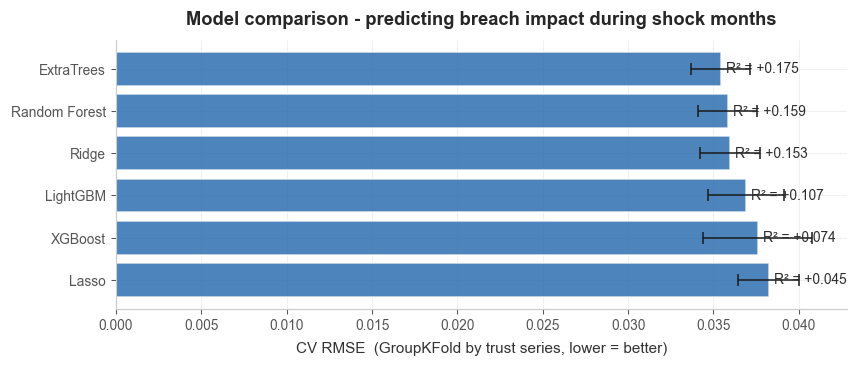

In [20]:
cv = GroupKFold(n_splits=5)

def cv_eval(make_fn, name):
    rmses, r2s = [], []
    for tr, te in cv.split(X, y, groups):
        mdl = make_fn()
        mdl.fit(X[tr], y[tr])
        pred = mdl.predict(X[te])
        rmses.append(np.sqrt(mean_squared_error(y[te], pred)))
        r2s.append(r2_score(y[te], pred))
    return {"model": name, "rmse": np.mean(rmses), "rmse_std": np.std(rmses), "r2": np.mean(r2s)}

results = [
    cv_eval(lambda: Pipeline([("sc", StandardScaler()), ("r", Ridge(alpha=1.0))]),       "Ridge"),
    cv_eval(lambda: Pipeline([("sc", StandardScaler()), ("r", Lasso(alpha=0.01, max_iter=5000))]), "Lasso"),
    cv_eval(lambda: ExtraTreesRegressor(
        n_estimators=400, max_depth=10, min_samples_leaf=3,
        random_state=RANDOM_STATE, n_jobs=-1),                                            "ExtraTrees"),
    cv_eval(lambda: RandomForestRegressor(
        n_estimators=400, max_depth=10, min_samples_leaf=3,
        random_state=RANDOM_STATE, n_jobs=-1),                                            "Random Forest"),
    cv_eval(lambda: xgb.XGBRegressor(
        n_estimators=400, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),                               "XGBoost"),
    cv_eval(lambda: lgb.LGBMRegressor(
        n_estimators=400, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),                                "LightGBM"),
]
res_df = pd.DataFrame(results).sort_values("rmse")
print(res_df.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.barh(res_df["model"], res_df["rmse"],
        xerr=res_df["rmse_std"], color=C_BLUE, alpha=0.80,
        capsize=4, error_kw={"linewidth": 1.0})
ax.invert_yaxis()
ax.set_xlabel("CV RMSE  (GroupKFold by trust series, lower = better)")
ax.set_title("Model comparison - predicting breach impact during shock months")
for i, (rmse, r2) in enumerate(zip(res_df["rmse"], res_df["r2"])):
    ax.text(rmse + 0.0003, i, f"R² = {r2:+.3f}", va="center", fontsize=9, color=C_DARK)
fig.tight_layout()
plt.show()


> **CV interpretation:** do not reuse the old R² ≈ 0.35-0.40 claim. Read the regenerated table directly. If R² remains close to zero or negative for most models, the correct finding is that shock-month deterioration is hard to predict out of sample from these pre-shock features, even if some features are useful descriptively. RMSE is in breach-rate units; multiply by 100 to express it as percentage points.

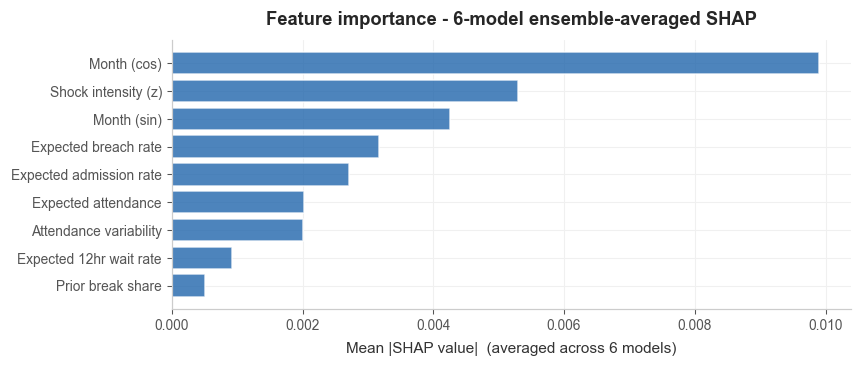

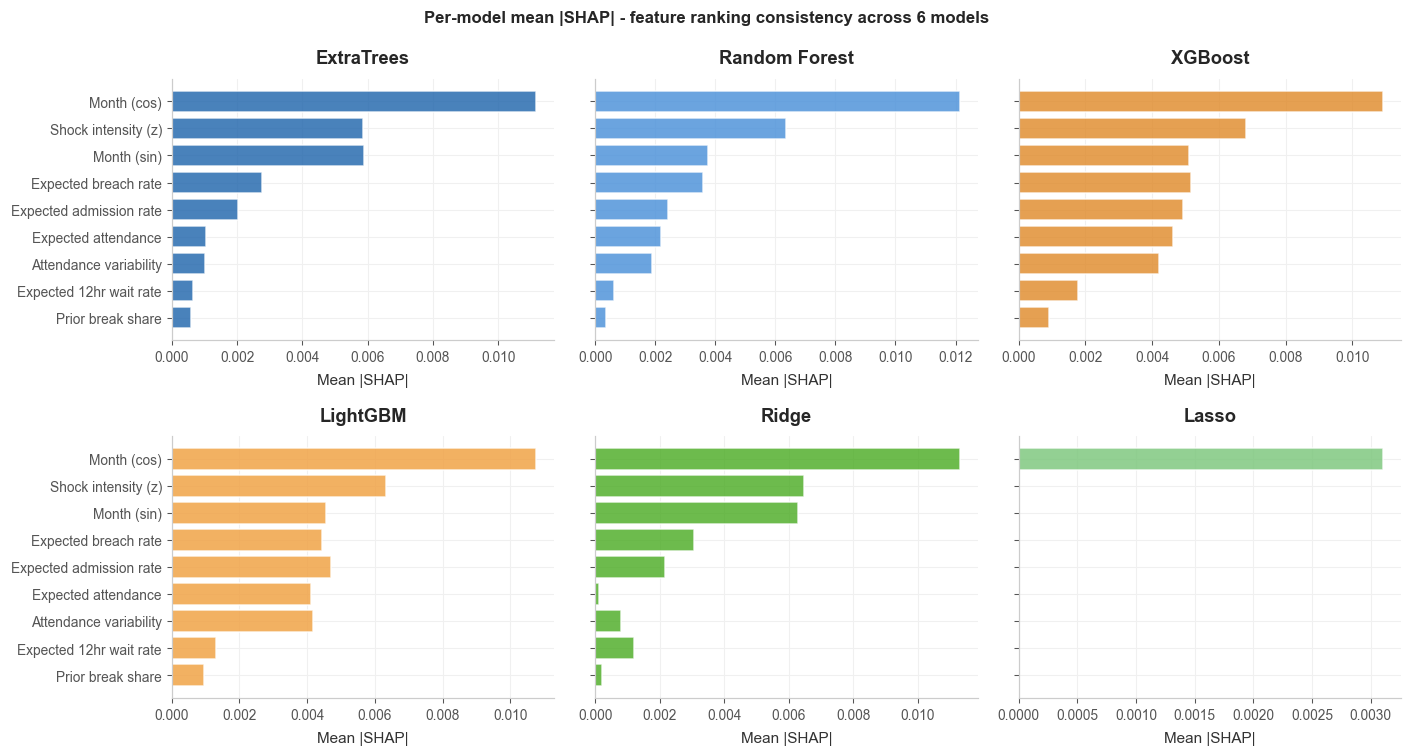

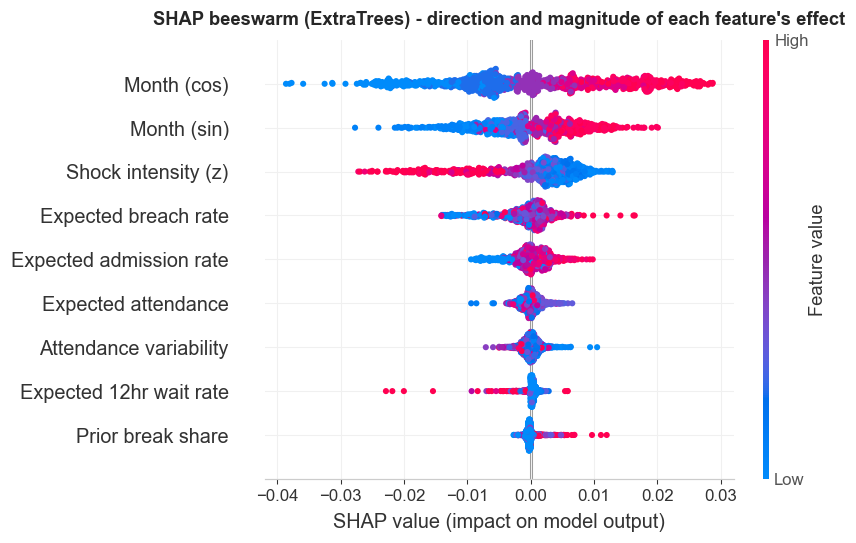

Additivity check - max |∑SHAP − (f(x)−E[f])| over 30 samples: 3.05e-16

Spearman ρ - feature importance rank correlation across models:
               ExtraTrees  Random Forest  XGBoost  LightGBM  Ridge  Lasso
ExtraTrees          1.000          0.983    0.950     0.900  0.867  0.548
Random Forest       0.983          1.000    0.983     0.933  0.883  0.548
XGBoost             0.950          0.983    1.000     0.917  0.867  0.548
LightGBM            0.900          0.933    0.917     1.000  0.867  0.548
Ridge               0.867          0.883    0.867     0.867  1.000  0.548
Lasso               0.548          0.548    0.548     0.548  0.548  1.000


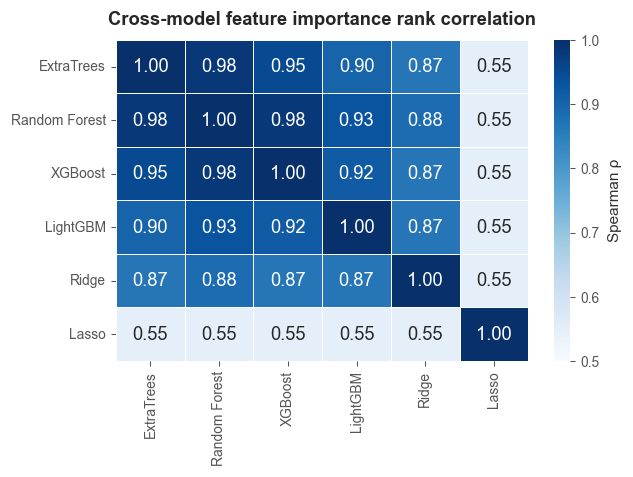

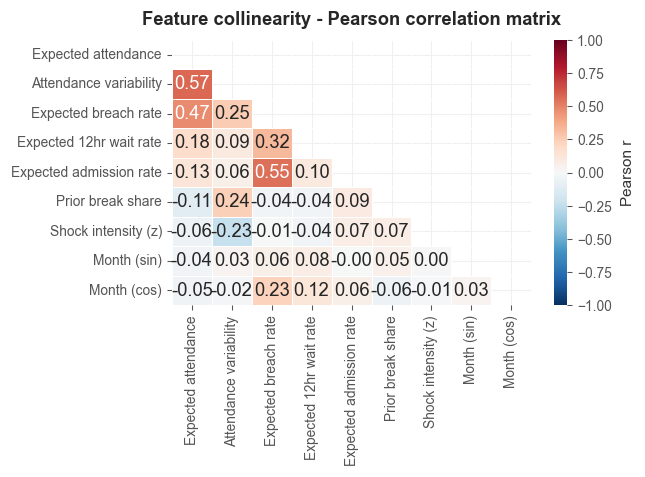


Feature pairs with |r| > 0.3:
  Attendance variability         ↔ Expected attendance             r = +0.574
  Expected admission rate        ↔ Expected breach rate            r = +0.553
  Expected breach rate           ↔ Expected attendance             r = +0.472
  Expected 12hr wait rate        ↔ Expected breach rate            r = +0.321


In [21]:
import shap
from scipy.stats import spearmanr

et_full    = ExtraTreesRegressor(n_estimators=400, max_depth=10, min_samples_leaf=3,
                                  random_state=RANDOM_STATE, n_jobs=-1)
rf_full    = RandomForestRegressor(n_estimators=400, max_depth=10, min_samples_leaf=3,
                                    random_state=RANDOM_STATE, n_jobs=-1)
xgb_full   = xgb.XGBRegressor(n_estimators=400, max_depth=4, learning_rate=0.05,
                                subsample=0.8, colsample_bytree=0.8,
                                random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)
lgb_full   = lgb.LGBMRegressor(n_estimators=400, max_depth=4, learning_rate=0.05,
                                 subsample=0.8, colsample_bytree=0.8,
                                 random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
ridge_full = Pipeline([("sc", StandardScaler()), ("r", Ridge(alpha=1.0))])
lasso_full = Pipeline([("sc", StandardScaler()), ("r", Lasso(alpha=0.01, max_iter=5000))])

for mdl in [et_full, rf_full, xgb_full, lgb_full, ridge_full, lasso_full]:
    mdl.fit(X, y)

et_explainer = shap.TreeExplainer(et_full)
shap_et      = et_explainer.shap_values(X)
ev           = float(np.squeeze(et_explainer.expected_value))

shap_rf  = shap.TreeExplainer(rf_full).shap_values(X)
shap_xgb = shap.TreeExplainer(xgb_full).shap_values(X)
shap_lgb = shap.TreeExplainer(lgb_full).shap_values(X)

X_sc       = ridge_full.named_steps["sc"].transform(X)
shap_ridge = shap.LinearExplainer(ridge_full.named_steps["r"], X_sc).shap_values(X_sc)
shap_lasso = shap.LinearExplainer(lasso_full.named_steps["r"], X_sc).shap_values(X_sc)

shap_values = shap_et

ALL_SHAP   = [shap_et, shap_rf, shap_xgb, shap_lgb, shap_ridge, shap_lasso]
ALL_LABELS = ["ExtraTrees", "Random Forest", "XGBoost", "LightGBM", "Ridge", "Lasso"]
ALL_COLS   = [C_BLUE, "#4A90D9", C_ORANGE, "#F0A040", C_GREEN, "#7BC67B"]

mean_abs_list = [np.abs(sv).mean(0) for sv in ALL_SHAP]

avg_shap = np.mean(mean_abs_list, axis=0)
order    = np.argsort(avg_shap)

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.barh([FEAT_LABELS[i] for i in order], avg_shap[order], color=C_BLUE, alpha=0.80)
ax.set_xlabel("Mean |SHAP value|  (averaged across 6 models)")
ax.set_title("Feature importance - 6-model ensemble-averaged SHAP", pad=10)
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharey=True)
for ax, ma, lbl, col in zip(axes.flat, mean_abs_list, ALL_LABELS, ALL_COLS):
    ax.barh([FEAT_LABELS[i] for i in order], ma[order], color=col, alpha=0.82)
    ax.set_title(lbl, fontweight="bold")
    ax.set_xlabel("Mean |SHAP|")
fig.suptitle("Per-model mean |SHAP| - feature ranking consistency across 6 models",
             fontsize=11, fontweight="bold")
fig.tight_layout()
plt.show()

shap.summary_plot(shap_values, features=X, feature_names=FEAT_LABELS, show=False)
plt.gcf().axes[0].set_title(
    "SHAP beeswarm (ExtraTrees) - direction and magnitude of each feature's effect", pad=10)
plt.tight_layout()
plt.show()

rng_idx  = np.random.default_rng(RANDOM_STATE).integers(0, len(X), 30)
shap_sum = shap_et[rng_idx].sum(axis=1)
residual = shap_sum - (et_full.predict(X[rng_idx]) - ev)
print(f"Additivity check - max |∑SHAP − (f(x)−E[f])| over 30 samples: {np.abs(residual).max():.2e}")

rank_mat = np.column_stack(mean_abs_list)
n_m      = len(ALL_LABELS)
rho_mat  = pd.DataFrame(
    [[spearmanr(rank_mat[:, i], rank_mat[:, j]).statistic for j in range(n_m)]
     for i in range(n_m)],
    index=ALL_LABELS, columns=ALL_LABELS,
)
print("\nSpearman ρ - feature importance rank correlation across models:")
print(rho_mat.round(3).to_string())

fig, ax = plt.subplots(figsize=(6, 4.5))
sns.heatmap(rho_mat, annot=True, fmt=".2f", cmap="Blues",
            vmin=0.5, vmax=1.0, linewidths=0.5, ax=ax,
            cbar_kws={"label": "Spearman ρ"})
ax.set_title("Cross-model feature importance rank correlation", pad=10)
fig.tight_layout()
plt.show()

feat_corr = pd.DataFrame(X, columns=FEAT_LABELS).corr()
fig, ax = plt.subplots(figsize=(6, 4.5))
mask = np.triu(np.ones_like(feat_corr, dtype=bool))
sns.heatmap(feat_corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            cbar_kws={"label": "Pearson r"})
ax.set_title("Feature collinearity - Pearson correlation matrix", pad=10)
fig.tight_layout()
plt.show()

high_corr = [(FEAT_LABELS[i], FEAT_LABELS[j], feat_corr.iloc[i, j])
             for i in range(len(FEAT_LABELS)) for j in range(i)
             if abs(feat_corr.iloc[i, j]) > 0.3]
print("\nFeature pairs with |r| > 0.3:")
for a, b, r in sorted(high_corr, key=lambda x: -abs(x[2])):
    print(f"  {a:30s} ↔ {b:30s}  r = {r:+.3f}")



Most resilient predicted shock month:
  Trust    : University Hospitals Coventry And Warwickshire NHS Trust
  Month    : Jun 2018
  Actual   : -0.0641
  Predicted: -0.0594


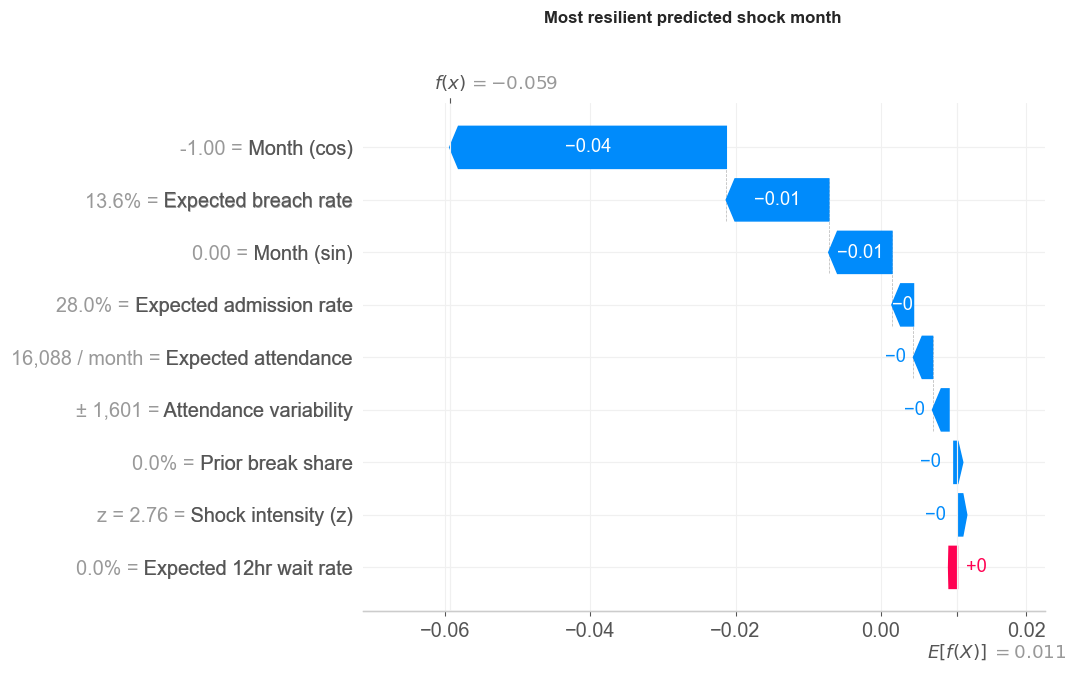


Most fragile predicted shock month:
  Trust    : Nottingham University Hospitals NHS Trust
  Month    : Feb 2019
  Actual   : +0.1493
  Predicted: +0.0830


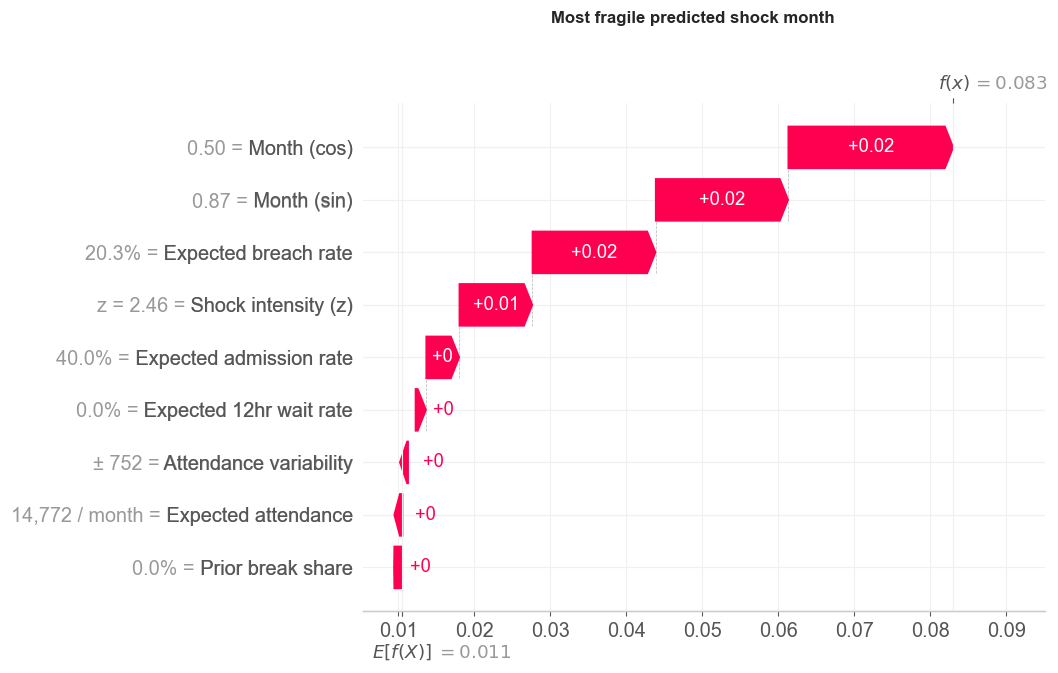

In [22]:
def _fmt_display(x_row):
    att, att_std, breach, w12, adm, brk, z, sin_, cos_ = x_row
    return [
        f"{att:,.0f} / month",
        f"± {att_std:,.0f}",
        f"{breach:.1%}",
        f"{w12:.1%}",
        f"{adm:.1%}",
        f"{brk:.1%}",
        f"z = {z:.2f}",
        f"{sin_:.2f}",
        f"{cos_:.2f}",
    ]

has_baseline = shock_df["expected_breach_rate_roll12"] > 0.01
preds = et_full.predict(X)
resilient_idx = shock_df[has_baseline].index[preds[has_baseline.values].argmin()]
fragile_idx = int(np.argmax(preds))

cases = [
    ("Most resilient predicted shock month", resilient_idx),
    ("Most fragile predicted shock month", fragile_idx),
]

for label, idx in cases:
    row = shock_df.iloc[idx]
    print(f"\n{label}:")
    print(f"  Trust    : {row['provider_name']}")
    print(f"  Month    : {pd.to_datetime(row['month']).strftime('%b %Y')}")
    print(f"  Actual   : {row[TARGET]:+.4f}")
    print(f"  Predicted: {preds[idx]:+.4f}")

    with plt.rc_context({"figure.figsize": (9, 5)}):
        shap.plots.waterfall(
            shap.Explanation(
                values=shap_values[idx],
                base_values=ev,
                data=X[idx],
                display_data=_fmt_display(X[idx]),
                feature_names=FEAT_LABELS,
            ),
            show=False,
        )
        plt.gcf().suptitle(label, fontsize=11, fontweight="bold", y=1.02)
        plt.show()


### SHAP Methodology and Cautions

| Check | Interpretation |
|---|---|
| Additivity | The numerical additivity check confirms that the SHAP values decompose the fitted model output correctly for the sampled cases. |
| Cross-model rank consistency | Use the printed Spearman matrix. Strong agreement across tree models is useful; weak agreement involving Lasso or other models means the ensemble-average plot should not be overclaimed. |
| Feature collinearity | Expected attendance, expected breach rate, expected 12-hour waits, and admission rate can proxy for related operational strain. Individual attribution splits within correlated groups are less reliable than their combined contribution. |
| In-sample SHAP vs out-of-sample R² | SHAP explains fitted model behaviour. It does not rescue weak cross-validated performance. If CV R² is low, interpret SHAP as descriptive rather than predictive proof. |
| Directionality | Directional claims should be based on the beeswarm and waterfall plots after rerunning the notebook, not on old saved outputs. |

The practical reading is: SHAP can identify which variables the fitted models use, but the strength of any substantive conclusion depends on the regenerated cross-validated performance table.


> **SHAP interpretation:** after rerunning, start with the CV results. If the models have weak out-of-sample R², the SHAP plots should be framed as exploratory evidence about fitted model behaviour. It is still reasonable to discuss whether expected breach rate, attendance scale, shock intensity, or operational-strain proxies appear influential, but avoid claims such as “all models agree”, “rank-1 across all models”, or “rules out artefact” unless the regenerated Spearman matrix and per-model bars clearly support them.

## 12. Conclusions and Limitations

**Main conclusion:** the notebook estimates how much each trust's 4-hour breach rate deteriorates during demand shocks relative to its own recent baseline. Trusts with lower shrunk breach impact are treated as more resilient. The final score is therefore an operational resilience ranking, not a general quality ranking.

**What the analysis supports:**

- demand shocks can be detected using same-calendar-month attendance baselines;
- trust-level breach behaviour is persistent enough to justify provider-level analysis;
- shrinkage is needed because some trusts have few shock observations;
- clustering can summarise broad resilient/moderate/fragile profiles for medium/high-evidence trusts;
- the tested geographic GCN should be treated as a negative or inconclusive result unless it outperforms the non-graph baseline after rerun.

**Key limitations:**

- the weekly-to-monthly conversion assigns weeks to the month of their end date;
- the resilience score depends on the shock threshold and the rolling baseline definition;
- low-evidence trusts remain uncertain even after shrinkage;
- SHAP explanations are only as strong as the predictive model's out-of-sample performance;
- observational features should not be interpreted causally without a stronger identification design.

**Recommended final reporting stance:** present the score and clusters as a decision-support tool for identifying trusts whose A&E performance appears more or less robust under unusually high demand, while being explicit that the ranking is sensitive to data quality, shock count, and the chosen baseline definition.
